In [138]:
# ============================================================
# FINAL PROJECT — PREDICTIVE ANALYTICS IN BANKING
# PT Bank Sentral Merakyat (BSM) — Prediksi Deposito Berjangka
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from matplotlib.ticker import FuncFormatter

# Statistics
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Display Config
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42

print("Libraries berhasil diimport")
print(f"Pandas version : {pd.__version__}")
print(f"NumPy version : {np.__version__}")

Libraries berhasil diimport
Pandas version : 3.0.2
NumPy version : 2.4.4


# PREDICTIVE ANALYTICS IN BANKING
## Prediksi Keberhasilan Kampanye Deposito Berjangka
### PT Bank Sentral Merakyat (BSM) — Divisi Data Science & Analytics

## A. BUSINESS UNDERSTANDING

### A.1 Background & Context

Pasca-pandemi COVID-19, PT Bank Sentral Merakyat (BSM) menghadapi tekanan ganda pada lini bisnis deposito berjangka.

Pada periode **2020–2021**, Bank Indonesia menurunkan suku bunga acuan (BI Rate) ke level terendah historis — 3,5% — untuk mendorong pemulihan ekonomi. Dampaknya: imbal hasil deposito tidak kompetitif dibandingkan instrumen lain seperti reksa dana pasar uang, Obligasi Ritel Indonesia (ORI), atau Sukuk Tabungan. Dana Pihak Ketiga (DPK) BSM pada segmen deposito berjangka mengalami stagnasi.

Memasuki **2022–2023**, Bank Indonesia memulai siklus pengetatan moneter secara agresif untuk meredam inflasi pasca-pandemi — BI Rate naik bertahap hingga menyentuh 6,0%. Kenaikan ini membuat deposito berjangka kembali menjadi instrumen investasi yang menarik bagi masyarakat.

BSM merespons peluang ini dengan meluncurkan **kampanye telemarketing** yang menargetkan:
1. Nasabah existing yang sebelumnya mengalihkan dana ke instrumen lain
2. Segmen prospek baru yang belum pernah berinvestasi di BSM

Tim Data Science BSM ditugaskan untuk membangun **model prediktif** yang mampu mengidentifikasi nasabah mana yang paling berpotensi menerima tawaran deposito berjangka — sehingga kampanye telemarketing dapat dijalankan lebih efisien dan tepat sasaran.

**Stakeholder utama:**
- **Chief Marketing Officer (CMO):** Butuh model untuk mengoptimalkan alokasi sumber daya call center
- **Tim Telemarketing:** Butuh daftar prioritas nasabah yang berpotensi tinggi
- **Tim Keuangan:** Butuh estimasi konversi untuk proyeksi DPK
- **Chief Risk Officer (CRO):** Butuh memastikan strategi tidak melanggar regulasi OJK terkait penjualan produk investasi

### A.2 Problem Statement

Berdasarkan konteks di atas, masalah yang dihadapi BSM dapat dirumuskan sebagai:

> **"Bagaimana memprediksi apakah seorang nasabah akan setuju membuka deposito berjangka di BSM melalui kampanye telemarketing, sehingga Tim Telemarketing dapat memprioritaskan kontak kepada nasabah dengan potensi konversi tertinggi?"**

Ini adalah masalah **klasifikasi biner**:
- **Kelas 1 (Subscribe = Yes):** Nasabah setuju membuka deposito berjangka
- **Kelas 0 (Subscribe = No):** Nasabah menolak tawaran

Tanpa model prediktif, Tim Telemarketing harus menghubungi semua nasabah secara acak — biaya tinggi, konversi rendah, dan banyak waktu agen yang terbuang.

### A.3 Cost of Errors — Mengapa FP dan FN Penting?

Dalam konteks kampanye telemarketing BSM, setiap kesalahan prediksi memiliki **dampak finansial yang asimetris**:

| Tipe | Prediksi | Realita | Skenario | Biaya |
|------|---------|---------|----------|-------|
| **True Positive (TP)** | Subscribe | Subscribe | Call relevan, nasabah berhasil dikonversi | Rp 50.000 (biaya 1 call) |
| **True Negative (TN)** | Tidak | Tidak | Nasabah tidak dihubungi, tidak ada biaya tambahan | Rp 0 |
| **False Positive (FP)** | Subscribe | Tidak | Call sia-sia, tidak ada konversi — waktu & biaya agen terbuang | Rp 50.000 |
| **False Negative (FN)** | Tidak | Subscribe | **Nasabah berharga terlewat, BSM kehilangan potensi margin deposito** | **Rp 500.000** |

#### Mengapa False Negative (FN) Jauh Lebih Fatal?

**Biaya per call (FP = Rp 50.000)** dihitung dari:
- Gaji telemarketer bank Indonesia: Rp 3.500.000–5.000.000/bulan
- Kapasitas: ~200 panggilan/bulan (10 call/hari × 20 hari kerja)
- Biaya gaji per call: Rp 17.500–25.000
- Ditambah overhead (VoIP, CRM, training, supervisor): ~100%
- **Total: ~Rp 35.000–50.000 per call** → digunakan Rp 50.000 (konservatif)

**Kehilangan per nasabah (FN = Rp 500.000)** dihitung dari:
- NIM (Net Interest Margin) rata-rata bank Indonesia: 4–5% per tahun (data OJK 2022)
- Rata-rata nominal deposito nasabah ritel BSM: ~Rp 50.000.000
- Gross spread: Rp 50 juta × 4% = Rp 2.000.000/tahun
- Setelah biaya operasional (~75% BOPO): **profit bersih ~Rp 500.000/nasabah/tahun**
- Belum termasuk: nilai cross-selling (KPR, kartu kredit), loyalitas jangka panjang

**Rasio biaya FN:FP = 10:1** → artinya setiap satu nasabah potensial yang terlewat setara kerugian 10 call sia-sia.

#### Kesimpulan: Minimasi False Negative adalah Prioritas Utama BSM.
Kita lebih baik *terlalu waspada* (menghubungi nasabah yang ternyata tidak mau) daripada *melewatkan* nasabah yang sebenarnya mau bergabung.

### A.4 Goals

**Goals Bisnis:**
1. Memprediksi nasabah yang berpotensi membuka deposito berjangka, sehingga Tim Telemarketing dapat fokus pada segmen berkonversi tinggi
2. Mengidentifikasi karakteristik demografis dan finansial "nasabah ideal" untuk deposito BSM
3. Mengoptimalkan biaya kampanye telemarketing dengan mengurangi call sia-sia (False Positive)
4. Memberikan rekomendasi strategis berbasis data: segmen mana yang diprioritaskan, timing terbaik, dan pendekatan yang efektif

**Goals Teknis:**
1. Membangun pipeline ML yang menghindari data leakage (stratified split, scaling dalam pipeline)
2. Menangani class imbalance (~89:11) dengan eksperimen resampling sistematis
3. Mengidentifikasi fitur-fitur dominan yang memengaruhi keputusan subscribe
4. Membangun model dengan F2-Score setinggi mungkin pada data test
5. Menentukan threshold optimal: F2-optimal (evaluasi model) dan Profit-optimal (deployment)
6. Menghitung simulasi ROI dalam Rupiah untuk memvalidasi nilai bisnis model

### A.5 Analytic Approach

Proyek ini menggunakan pendekatan **hybrid: Analytics + Machine Learning**:

**Analytics (Descriptive + Inferential):**
- Exploratory Data Analysis (EDA) mendalam dengan framework 5W-1H
- Uji signifikansi statistik formal (Chi-Square untuk kategorikal, T-test/ANOVA untuk numerikal)
- Segmentasi nasabah berbasis temuan EDA

**Machine Learning (Predictive):**
- Benchmarking sistematis: 6 algoritma × 5 strategi resampling = 30 kombinasi
- Hyperparameter tuning pada kombinasi terbaik
- Dual-threshold optimization: F2-optimal dan Profit-optimal (dalam Rupiah)

**Catatan penting — Duration Paradox:**
Kolom `duration` (durasi panggilan terakhir dalam detik) **mengandung data leakage**: nilainya hanya bisa diketahui *setelah* panggilan selesai, bukan *sebelum*. Oleh karena itu:
- `duration` **DIGUNAKAN** di bagian Analytics/EDA untuk mendapatkan insight
- `duration` **DIHAPUS** sebelum memasuki bagian Machine Learning

### A.6 Evaluation Metrics

**Metrik Utama: F2-Score**

$$F_2 = 5 \cdot \frac{\text{Precision} \times \text{Recall}}{4 \times \text{Precision} + \text{Recall}}$$

Dengan beta = 2, F2-Score memberikan **bobot 2× lebih besar pada Recall** dibandingkan Precision.

**Mengapa F2, bukan metrik lain?**

| Metrik | Masalah dalam Konteks BSM |
|--------|--------------------------|
| Accuracy | Misleading pada data imbalanced. Model yang selalu prediksi "tidak" punya akurasi 89% tapi tidak berguna |
| Recall murni | Recall 100% tercapai dengan prediksi "semua subscribe" → 41.000+ call sia-sia, ROI negatif |
| F1-Score | Bobot sama untuk FP dan FN, padahal FN 10× lebih mahal dari FP |
| **F2-Score** | Prioritaskan Recall (minimasi FN), tapi Precision tetap dijaga agar ROI positif |

**Metrik Pendukung:**

| Metrik | Fungsi |
|--------|--------|
| Recall | Berapa % nasabah yang mau terdeteksi — prioritas utama BSM |
| ROC-AUC | Kemampuan diskriminasi model secara keseluruhan |
| Precision | Monitoring agar call center tidak overload dengan false alarms |
| **Savings (Rp)** | **Metrik bisnis final: penghematan vs tanpa model** |
| ROI (%) | Return on Investment dari implementasi model |

## B. DATA UNDERSTANDING

### B.1 Import Libraries
*(Library sudah diimport pada cell pertama di atas)*

In [139]:
# 
# B.2 Load Dataset + Fix Macro Indicator Columns
# 

# Load dataset
df = pd.read_csv('bank-additional-full.csv', sep=';')

print("=" * 60)
print("DATASET BERHASIL DIMUAT")
print("=" * 60)
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")
print(f"\n5 Baris Pertama:")
display(df.head())
print(f"\n5 Baris Terakhir:")
display(df.tail())

DATASET BERHASIL DIMUAT
Jumlah baris : 41,188
Jumlah kolom : 21

5 Baris Pertama:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no



5 Baris Terakhir:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",no


In [140]:
# 
# FIX: Kolom Macro Indicator tersimpan sebagai object
# karena menggunakan koma sebagai pemisah desimal (format Eropa)
# Action : Ganti koma → titik, lalu konversi ke float
# Why : Kolom-kolom ini adalah fitur numerik yang krusial
# (JIBOR, IHK, IKK, dll). Jika dibiarkan sebagai object,
# model tidak bisa membacanya sebagai angka.
# Business Impact: Macro indicators adalah konteks ekonomi yang
# menjelaskan MENGAPA nasabah mau/tidak mau deposito.
# 

macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']

print("Tipe data SEBELUM fix:")
print(df[macro_cols].dtypes.to_string())
print()

for col in macro_cols:
 df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

print("Tipe data SESUDAH fix:")
print(df[macro_cols].dtypes.to_string())
print()
print("Sample nilai setelah fix:")
display(df[macro_cols].head(3))

Tipe data SEBELUM fix:
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
nr.employed       float64

Tipe data SESUDAH fix:
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
nr.employed       float64

Sample nilai setelah fix:


,emp.var.rate,cons.price.idx,cons.conf.idx,nr.employed
0,1.1000,93.9940,-36.4000,"5,191.0000"
1,1.1000,93.9940,-36.4000,"5,191.0000"
2,1.1000,93.9940,-36.4000,"5,191.0000"


In [141]:
# 
# B.3 Dataset Overview — Info, Describe, Deskripsi Kolom
# 

print("=" * 60)
print("INFORMASI TIPE DATA & NON-NULL COUNT")
print("=" * 60)
df.info()

INFORMASI TIPE DATA & NON-NULL COUNT
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.

In [142]:
print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF — FITUR NUMERIK")
print("=" * 60)
display(df.describe())


STATISTIK DESKRIPTIF — FITUR NUMERIK


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,"41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000"
mean,40.0241,258.2850,2.5676,962.4755,0.1730,0.0819,93.5757,-40.5026,3.6213,"5,167.0359"
std,10.4212,259.2792,2.7700,186.9109,0.4949,1.5710,0.5788,4.6282,1.7344,72.2515
min,17.0000,0.0000,1.0000,0.0000,0.0000,-3.4000,92.2010,-50.8000,0.6340,"4,963.6000"
25%,32.0000,102.0000,1.0000,999.0000,0.0000,-1.8000,93.0750,-42.7000,1.3440,"5,099.1000"
50%,38.0000,180.0000,2.0000,999.0000,0.0000,1.1000,93.7490,-41.8000,4.8570,"5,191.0000"
75%,47.0000,319.0000,3.0000,999.0000,0.0000,1.4000,93.9940,-36.4000,4.9610,"5,228.1000"
max,98.0000,"4,918.0000",56.0000,999.0000,7.0000,1.4000,94.7670,-26.9000,5.0450,"5,228.1000"


In [143]:
print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF — FITUR KATEGORIKAL")
print("=" * 60)
display(df.describe(include='object'))


STATISTIK DESKRIPTIF — FITUR KATEGORIKAL


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


#### Deskripsi Variabel Dataset

**Demografi & Profil Nasabah:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `age` | Numerik | Usia nasabah (tahun) |
| `job` | Kategorikal | Kategori pekerjaan (admin, blue-collar, entrepreneur, dll) |
| `marital` | Kategorikal | Status pernikahan (single, married, divorced) |
| `education` | Kategorikal | Tingkat pendidikan (ordinal: illiterate → university.degree) |
| `default` | Kategorikal | Riwayat kredit macet? (yes, no, unknown) |
| `housing` | Kategorikal | Punya pinjaman KPR? (yes, no, unknown) |
| `loan` | Kategorikal | Punya pinjaman pribadi? (yes, no, unknown) |

**Kampanye Saat Ini:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `contact` | Kategorikal | Jenis kontak (cellular / telephone) |
| `month` | Kategorikal | Bulan terakhir dihubungi |
| `day_of_week` | Kategorikal | Hari terakhir dihubungi |
| `duration` | Numerik | Durasi call terakhir (detik) — **HANYA untuk EDA, tidak masuk model** |
| `campaign` | Numerik | Jumlah kontak dalam kampanye ini |

**Riwayat Kampanye Sebelumnya:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `pdays` | Numerik | Hari sejak kontak kampanye sebelumnya (999 = belum pernah) |
| `previous` | Numerik | Jumlah kontak sebelum kampanye ini |
| `poutcome` | Kategorikal | Hasil kampanye sebelumnya (success, failure, nonexistent) |

**Macro Economic Indicators (Konteks BSM Indonesia):**
| Kolom | Tipe | Interpretasi untuk BSM |
|-------|------|----------------------|
| `emp.var.rate` | Numerik | Pertumbuhan Ketenagakerjaan YoY (Sakernas BPS) |
| `cons.price.idx` | Numerik | Indeks Harga Konsumen / IHK (BPS) |
| `cons.conf.idx` | Numerik | Indeks Keyakinan Konsumen / IKK (Survei BI) |
| `euribor3m` | Numerik | JIBOR 3 Bulan / Proksi BI Rate |
| `nr.employed` | Numerik | Jumlah Angkatan Kerja Aktif (juta orang, BPS) |

**Target Variable:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `y` | Kategorikal | Setuju membuka deposito berjangka? (yes / no) |

In [144]:
# 
# B.4 Missing Values Analysis
#
# PENTING: Dataset ini menggunakan string "unknown" sebagai
# representasi missing values — BUKAN NaN/null!
# df.isnull().sum() akan mengembalikan 0 untuk semua kolom
# padahal ada missing values yang tersembunyi.
#
# Langkah: Deteksi "unknown" terlebih dahulu sebelum
# menggantinya dengan NaN untuk analisis missingno.
# 

print("=" * 60)
print("CEK MISSING VALUES EKSPLISIT (NaN/null)")
print("=" * 60)
explicit_missing = df.isnull().sum()
if explicit_missing.sum() == 0:
 print("Tidak ada NaN/null eksplisit dalam dataset.")
 print(" TAPI perlu dicek: missing values mungkin direpresentasikan")
 print(" sebagai string 'unknown'!")
else:
 print(explicit_missing[explicit_missing > 0])

CEK MISSING VALUES EKSPLISIT (NaN/null)
Tidak ada NaN/null eksplisit dalam dataset.
 TAPI perlu dicek: missing values mungkin direpresentasikan
 sebagai string 'unknown'!


In [145]:
# Deteksi "unknown" per kolom
print("\n" + "=" * 60)
print("DETEKSI 'unknown' SEBAGAI MISSING VALUES TERSEMBUNYI")
print("=" * 60)

unknown_summary = []
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
 n_unknown = (df[col] == 'unknown').sum()
 pct_unknown = n_unknown / len(df) * 100
 if n_unknown > 0:
     unknown_summary.append({
 'Kolom': col,
 'Jumlah Unknown': n_unknown,
 'Persentase (%)': round(pct_unknown, 2)
 })

if unknown_summary:
 unknown_df = pd.DataFrame(unknown_summary).sort_values('Persentase (%)', ascending=False)
 print(unknown_df.to_string(index=False))
 print(f"\nTotal kolom dengan 'unknown': {len(unknown_df)}")
else:
 print("Tidak ada nilai 'unknown' ditemukan.")


DETEKSI 'unknown' SEBAGAI MISSING VALUES TERSEMBUNYI
    Kolom  Jumlah Unknown  Persentase (%)
  default            8597         20.8700
education            1731          4.2000
  housing             990          2.4000
     loan             990          2.4000
      job             330          0.8000
  marital              80          0.1900

Total kolom dengan 'unknown': 6


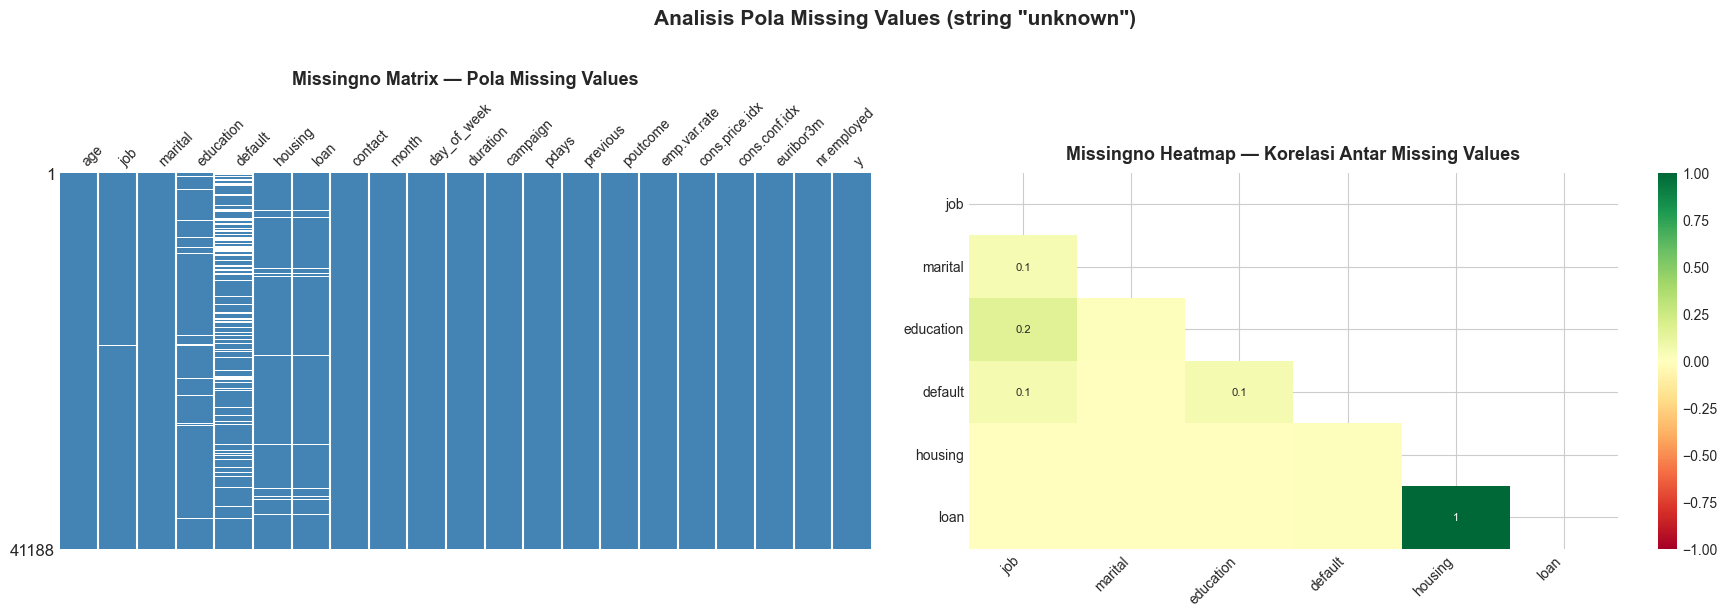

Plot disimpan sebagai 'missing_values_analysis.png'


In [146]:
# Missingno Analysis — ganti "unknown" ke NaN sementara untuk visualisasi
df_for_msno = df.copy()
df_for_msno.replace('unknown', np.nan, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Matrix
msno.matrix(df_for_msno, ax=axes[0], sparkline=False, fontsize=10,
 color=(0.27, 0.52, 0.71))
axes[0].set_title('Missingno Matrix — Pola Missing Values', 
 fontsize=13, fontweight='bold', pad=10)

# Heatmap
msno.heatmap(df_for_msno, ax=axes[1], fontsize=10, cmap='RdYlGn')
axes[1].set_title('Missingno Heatmap — Korelasi Antar Missing Values', 
 fontsize=13, fontweight='bold', pad=10)

plt.suptitle('Analisis Pola Missing Values (string "unknown")', 
 fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('missing_values_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

del df_for_msno
print("Plot disimpan sebagai 'missing_values_analysis.png'")

<Figure size 1000x500 with 0 Axes>

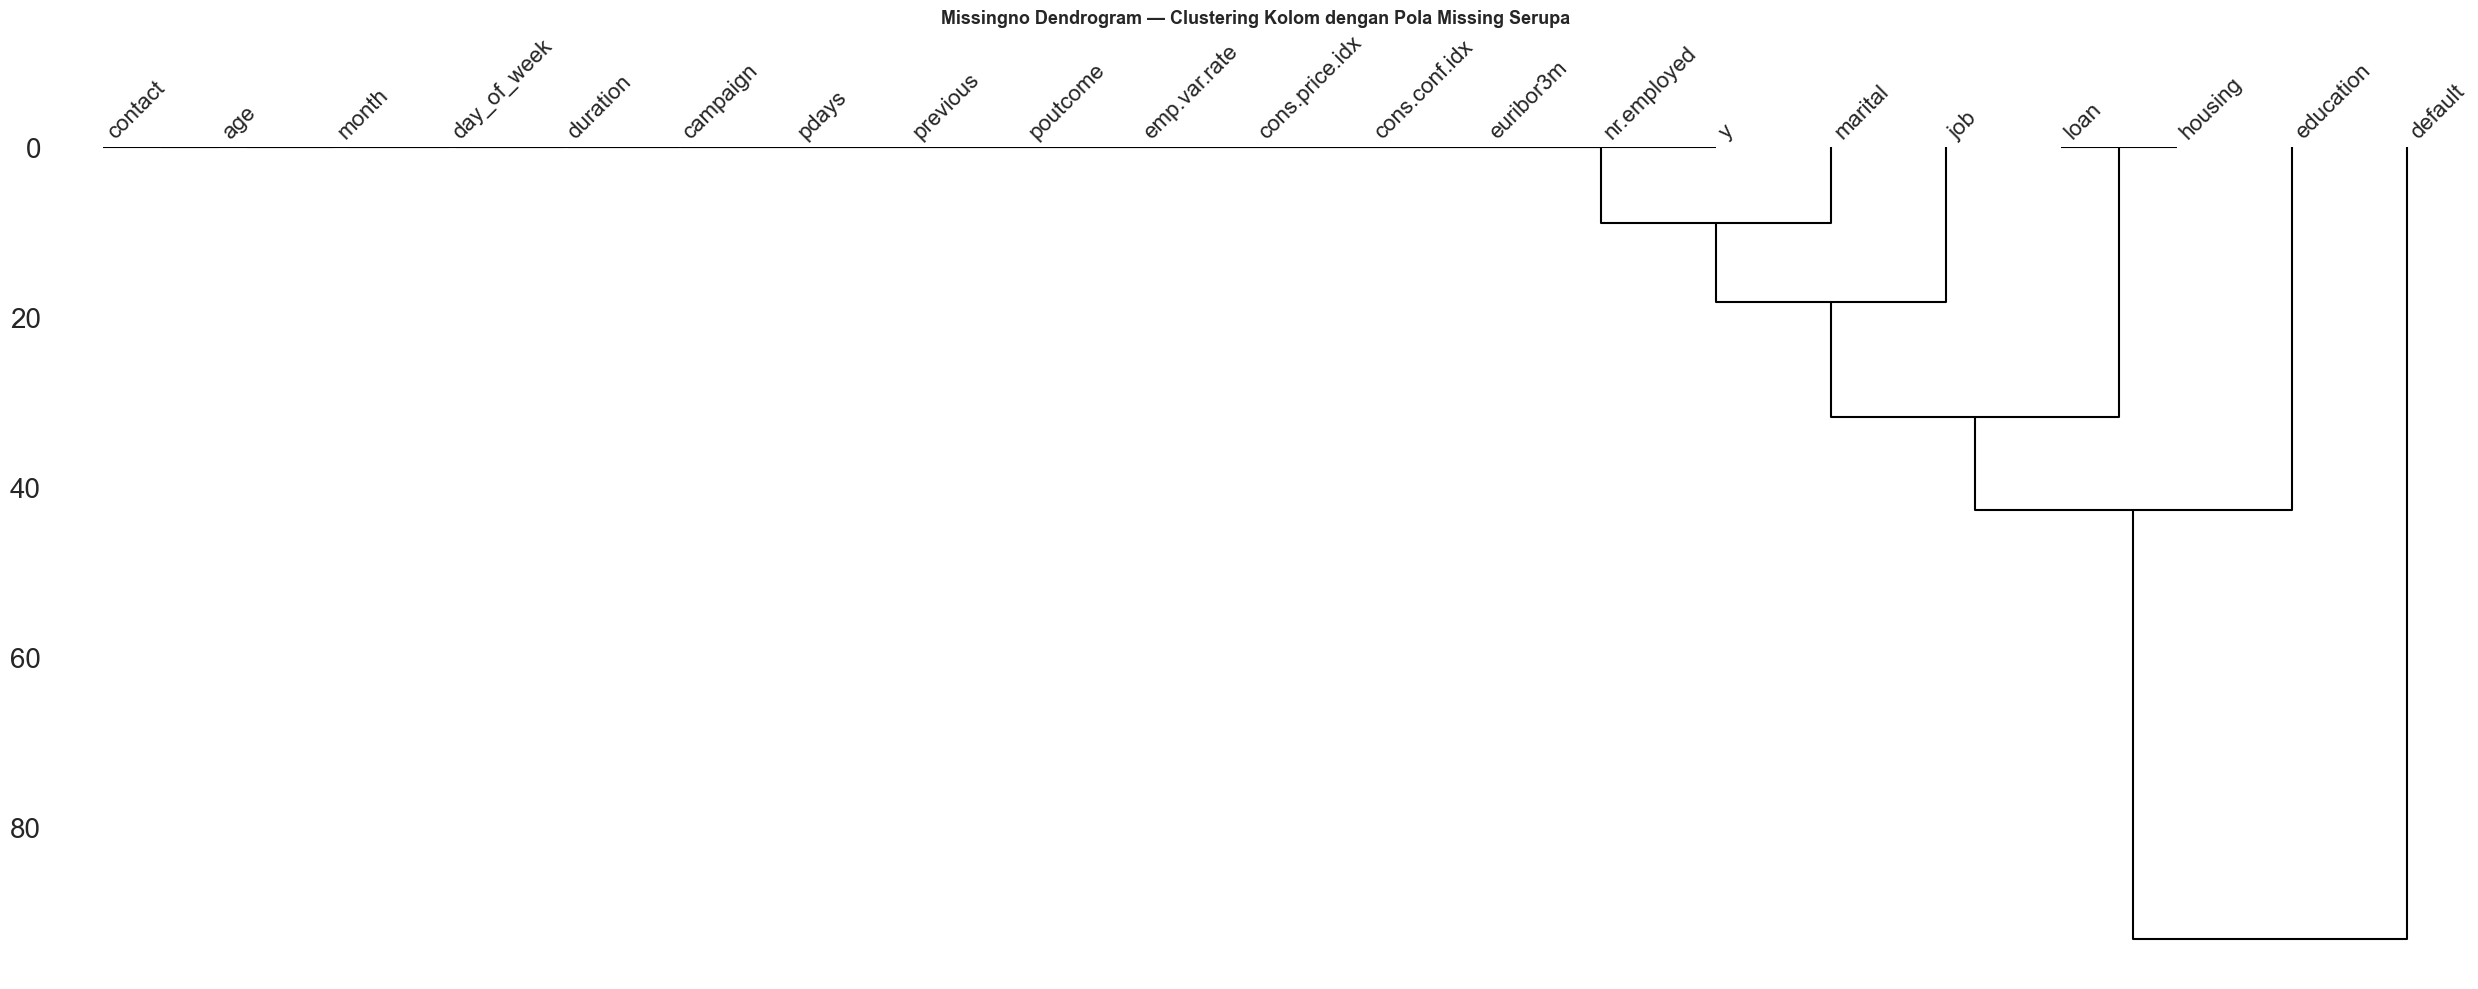

Plot disimpan sebagai 'missing_dendrogram.png'


In [147]:
# Dendrogram — clustering pola missing
df_for_dendro = df.copy()
df_for_dendro.replace('unknown', np.nan, inplace=True)

plt.figure(figsize=(10, 5))
msno.dendrogram(df_for_dendro)
plt.title('Missingno Dendrogram — Clustering Kolom dengan Pola Missing Serupa',
 fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

del df_for_dendro
print("Plot disimpan sebagai 'missing_dendrogram.png'")

In [148]:
# 
# B.5 Duplicate Check
# 

dup_count = df.duplicated().sum()
print("=" * 60)
print("CEK DATA DUPLIKAT")
print("=" * 60)
print(f"Jumlah baris duplikat : {dup_count:,}")
print(f"Persentase duplikat : {dup_count/len(df)*100:.2f}%")

if dup_count > 0:
 print("\nContoh baris duplikat (5 pertama):")
 display(df[df.duplicated(keep=False)].head())
else:
 print("\nTidak ada data duplikat.")

CEK DATA DUPLIKAT
Jumlah baris duplikat : 12
Persentase duplikat : 0.03%

Contoh baris duplikat (5 pertama):


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8550,"5,191.0000",no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8550,"5,191.0000",no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9660,"5,228.1000",no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9660,"5,228.1000",no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9620,"5,228.1000",no


In [149]:
# 
# B.6 Distribusi Target Variable (Class Imbalance Check)
# 

target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

print("=" * 60)
print("DISTRIBUSI TARGET VARIABLE (y: subscribe deposito?)")
print("=" * 60)
for label in target_counts.index:
 bar = "" * int(target_pct[label])
 print(f" {label:>3} : {target_counts[label]:,} ({target_pct[label]:.2f}%) {bar}")

ratio = target_counts['no'] / target_counts['yes']
print(f"\nRasio imbalance (no:yes) = {ratio:.1f}:1")
print(f"\nDataset menunjukkan CLASS IMBALANCE.")
print(f" Teknik resampling WAJIB digunakan dalam tahap pemodelan.")

DISTRIBUSI TARGET VARIABLE (y: subscribe deposito?)
  no : 36,548 (88.73%) 
 yes : 4,640 (11.27%) 

Rasio imbalance (no:yes) = 7.9:1

Dataset menunjukkan CLASS IMBALANCE.
 Teknik resampling WAJIB digunakan dalam tahap pemodelan.


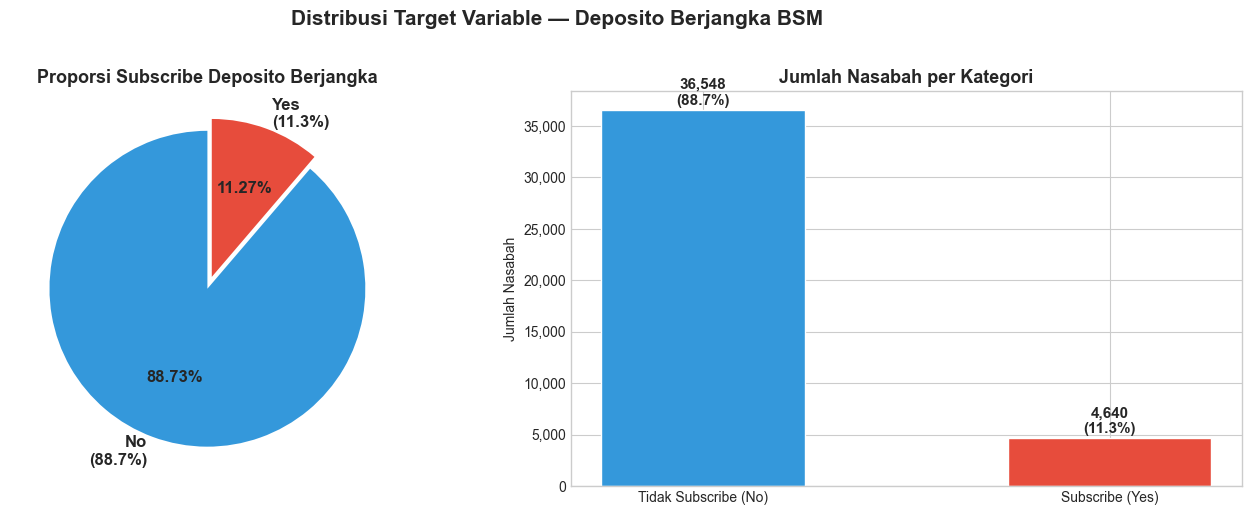

Plot disimpan sebagai 'target_distribution.png'


In [150]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#3498db', '#e74c3c']
explode = (0, 0.08)
axes[0].pie(
 target_counts.values,
 labels=[f'No\n({target_pct["no"]:.1f}%)', f'Yes\n({target_pct["yes"]:.1f}%)'],
 colors=colors,
 explode=explode,
 autopct='%1.2f%%',
 startangle=90,
 textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[0].set_title('Proporsi Subscribe Deposito Berjangka', 
 fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(
 ['Tidak Subscribe (No)', 'Subscribe (Yes)'],
 target_counts.values,
 color=colors,
 edgecolor='white',
 width=0.5
)
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
 axes[1].text(
 bar.get_x() + bar.get_width()/2.,
 bar.get_height() + 200,
 f'{count:,}\n({pct:.1f}%)',
 ha='center', va='bottom', fontweight='bold', fontsize=11
 )
axes[1].set_title('Jumlah Nasabah per Kategori', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Nasabah')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribusi Target Variable — Deposito Berjangka BSM',
 fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'target_distribution.png'")

In [151]:
# 
# B.7 Kesimpulan Data Understanding
# 

print(f"\nDIMENSI DATASET:")
print(f" Baris : {df.shape[0]:,}")
print(f" Kolom : {df.shape[1]}")

print(f"\nTIPE DATA:")
dtype_summary = df.dtypes.value_counts()
for dtype, count in dtype_summary.items():
 print(f" {str(dtype):<12}: {count} kolom")

print(f"\nSTATUS KOLOM MACRO (setelah fix):")
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
for col in macro_cols:
 print(f" {col:<20}: {df[col].dtype}")

print(f"\nMISSING VALUES ('unknown'):")
cat_cols = df.select_dtypes(include='object').columns
any_unknown = False
for col in cat_cols:
 n = (df[col] == 'unknown').sum()
 if n > 0:
     print(f" {col:<15}: {n:,} ({n/len(df)*100:.1f}%)")
 any_unknown = True
if not any_unknown:
 print(" Tidak ada 'unknown' ditemukan.")

print(f"\nDUPLIKAT:")
dup = df.duplicated().sum()
print(f" {dup:,} baris duplikat ({dup/len(df)*100:.2f}%)")

print(f"\nTARGET VARIABLE (y):")
for label in df['y'].value_counts().index:
 cnt = df['y'].value_counts()[label]
 pct = df['y'].value_counts(normalize=True)[label] * 100
 print(f" {label:>3}: {cnt:,} ({pct:.2f}%)")
ratio = df['y'].value_counts()['no'] / df['y'].value_counts()['yes']
print(f" Rasio no:yes = {ratio:.1f}:1")

print(f"\nSTATISTIK NUMERIK RINGKAS:")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f" Jumlah fitur numerik: {len(num_cols)}")
print(f" Kolom: {num_cols}")

print(f"\nCATATAN PENTING UNTUK tahap sebelumnya:")
print(f" 1. {len([c for c in df.select_dtypes('object').columns if (df[c]=='unknown').sum()>0])} kolom memiliki 'unknown' yang perlu ditangani")
print(f" 2. Kolom 'duration' berpotensi data leakage → drop sebelum ML")
print(f" 3. Class imbalance rasio {ratio:.0f}:1 → wajib resampling")
print(f" 4. Lihat missingno plot untuk pola missing sebelum memutuskan imputasi")
print("=" * 70)


DIMENSI DATASET:
 Baris : 41,188
 Kolom : 21

TIPE DATA:
 str         : 11 kolom
 int64       : 5 kolom
 float64     : 5 kolom

STATUS KOLOM MACRO (setelah fix):
 emp.var.rate        : float64
 cons.price.idx      : float64
 cons.conf.idx       : float64
 nr.employed         : float64

MISSING VALUES ('unknown'):
 job            : 330 (0.8%)
 marital        : 80 (0.2%)
 education      : 1,731 (4.2%)
 default        : 8,597 (20.9%)
 housing        : 990 (2.4%)
 loan           : 990 (2.4%)

DUPLIKAT:
 12 baris duplikat (0.03%)

TARGET VARIABLE (y):
  no: 36,548 (88.73%)
 yes: 4,640 (11.27%)
 Rasio no:yes = 7.9:1

STATISTIK NUMERIK RINGKAS:
 Jumlah fitur numerik: 10
 Kolom: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

CATATAN PENTING UNTUK tahap sebelumnya:
 1. 6 kolom memiliki 'unknown' yang perlu ditangani
 2. Kolom 'duration' berpotensi data leakage → drop sebelum ML
 3. Class imbalance rasio 8:1 →

In [152]:
# 
# Tambahan import untuk tahap selanjutnya — Data Cleaning
# 

# Verifikasi df tersedia (jalankan ulang B.2 jika kernel di-restart)
try:
 _ = df.shape
 print(f"DataFrame tersedia: {df.shape[0]:,} baris × {df.shape[1]} kolom")
except NameError:
 print(" DataFrame tidak ditemukan — jalankan cells tahap sebelumnya terlebih dahulu (B.2)")
 print(" Atau jalankan cell reload di bawah ini.")

DataFrame tersedia: 41,188 baris × 21 kolom


In [153]:
# 
# RELOAD DATASET (jalankan hanya jika df tidak tersedia)
# 

df = pd.read_csv('bank-additional-full.csv', sep=';')

# Fix macro indicator columns (sama persis dengan tahap sebelumnya B.2)
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
for col in macro_cols:
 df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

print(f"Dataset di-reload: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f" Macro columns sudah difix ke float.")

Dataset di-reload: 41,188 baris × 21 kolom
 Macro columns sudah difix ke float.


---
## C. DATA CLEANING & OUTLIER ANALYSIS

> **Konteks Phase ini:** Berdasarkan temuan sebelumnya (Data Understanding), ditemukan tiga isu utama
> yang perlu ditangani sebelum modeling: (1) 12 baris duplikat, (2) nilai 'unknown' pada 6 kolom
> kategorikal, dan (3) potensi outlier pada beberapa fitur numerik.
> Setiap keputusan cleaning didokumentasikan dengan alasan teknis dan dampak bisnis.

In [154]:
# 
# C.1 Handle Duplicate Rows
#
# Action : Drop baris duplikat (keep='first')
# Why : 12 baris duplikat (0.03%) bisa menyebabkan model
# "menghafal" observasi tertentu dua kali, mengganggu
# distribusi pada stratified split.
# Business Impact: Minimal — 12 baris dari 41.188 tidak
# mengubah distribusi secara material, namun
# menghilangkan redundansi data yang tidak perlu.
# 

print("=" * 60)
print("C.1 HANDLE DUPLICATE ROWS")
print("=" * 60)

before = df.shape[0]
df = df.drop_duplicates(keep='first').reset_index(drop=True)
after = df.shape[0]
dropped = before - after

print(f"Baris sebelum drop duplikat : {before:,}")
print(f"Baris setelah drop duplikat : {after:,}")
print(f"Baris yang di-drop : {dropped:,} ({dropped/before*100:.2f}%)")
print(f"\nDuplikat berhasil dihapus. Dataset bersih: {after:,} baris.")

C.1 HANDLE DUPLICATE ROWS
Baris sebelum drop duplikat : 41,188
Baris setelah drop duplikat : 41,176
Baris yang di-drop : 12 (0.03%)

Duplikat berhasil dihapus. Dataset bersih: 41,176 baris.


**Insight:** Ditemukan 12 baris duplikat (0.03% dari total data). Setelah di-drop,
dataset tersisa 41.176 baris. Jumlah yang dihapus sangat kecil sehingga tidak
mengubah distribusi kelas maupun karakteristik statistik dataset secara material.

**Business Recommendation:**
Kemunculan duplikat kemungkinan berasal dari proses ETL (extract-transform-load)
yang menggabungkan data dari beberapa sumber call center BSM. Tim Data Engineering
sebaiknya menambahkan constraint deduplikasi berbasis kombinasi (nasabahId + tanggal_call)
di pipeline ingest untuk mencegah duplikat masuk ke sistem analitik ke depannya.

In [155]:
# 
# C.2 Handle 'unknown' Values
#
# Langkah 1: Cek apakah 'unknown' bersifat MCAR, MAR, atau MNAR
# untuk menentukan strategi penanganan yang tepat.
#
# Temuan dari tahap sebelumnya:
# - housing & loan: tepat 990 baris masing-masing → diduga rows yg sama
# - default: 20.87% → terlalu tinggi untuk imputasi yang reliable
# - education: 4.2% → ordinal, 'unknown' bisa jadi kategori sendiri
# - job & marital: < 1% → kecil, tapi tetap perlu penanganan konsisten
# 

print("=" * 60)
print("C.2 INVESTIGASI POLA 'unknown'")
print("=" * 60)

cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# Cek apakah housing & loan unknown berasal dari rows yang sama
housing_unk_idx = set(df[df['housing'] == 'unknown'].index)
loan_unk_idx = set(df[df['loan'] == 'unknown'].index)
overlap = housing_unk_idx & loan_unk_idx

print(f"\n[Cek Overlap housing & loan 'unknown']")
print(f" Jumlah rows dengan housing='unknown' : {len(housing_unk_idx):,}")
print(f" Jumlah rows dengan loan='unknown' : {len(loan_unk_idx):,}")
print(f" Overlap (sama persis) : {len(overlap):,}")
if len(overlap) == len(housing_unk_idx) == len(loan_unk_idx):
 print(f" → Konfirmasi: housing & loan unknown SELALU co-occur pada rows yang SAMA.")
 print(f" → Pola ini menunjukkan MAR (Missing At Random) atau MCAR — nasabah yang")
 print(f" tidak mengisi data pinjaman biasanya tidak mengisi keduanya sekaligus.")

C.2 INVESTIGASI POLA 'unknown'

[Cek Overlap housing & loan 'unknown']
 Jumlah rows dengan housing='unknown' : 990
 Jumlah rows dengan loan='unknown' : 990
 Overlap (sama persis) : 990
 → Konfirmasi: housing & loan unknown SELALU co-occur pada rows yang SAMA.
 → Pola ini menunjukkan MAR (Missing At Random) atau MCAR — nasabah yang
 tidak mengisi data pinjaman biasanya tidak mengisi keduanya sekaligus.


In [156]:
# Investigasi: apakah 'unknown' berasosiasi dengan subscribe rate yang berbeda?
# Jika iya → 'unknown' bersifat INFORMATIF (tidak boleh diimputasi sembarangan)
print("\n" + "=" * 60)
print("CEK SUBSCRIBE RATE PER KATEGORI (termasuk 'unknown')")
print("=" * 60)

for col in cols_with_unknown:
 print(f"\n--- {col.upper()} ---")
 cross = df.groupby(col)['y'].value_counts(normalize=True).unstack().fillna(0)
 cross['subscribe_rate_%'] = (cross.get('yes', 0) * 100).round(2)
 cross['n'] = df[col].value_counts()
 print(cross[['n', 'subscribe_rate_%']].sort_values('subscribe_rate_%', ascending=False).to_string())


CEK SUBSCRIBE RATE PER KATEGORI (termasuk 'unknown')

--- JOB ---
y                  n  subscribe_rate_%
job                                   
student          875           31.4300
retired         1718           25.2600
unemployed      1014           14.2000
admin.         10419           12.9700
management      2924           11.2200
unknown          330           11.2100
technician      6739           10.8300
self-employed   1421           10.4900
housemaid       1060           10.0000
entrepreneur    1456            8.5200
services        3967            8.1400
blue-collar     9253            6.9000

--- MARITAL ---
y             n  subscribe_rate_%
marital                          
unknown      80           15.0000
single    11564           14.0100
divorced   4611           10.3200
married   24921           10.1600

--- EDUCATION ---
y                        n  subscribe_rate_%
education                                   
illiterate              18           22.2200
unknown     

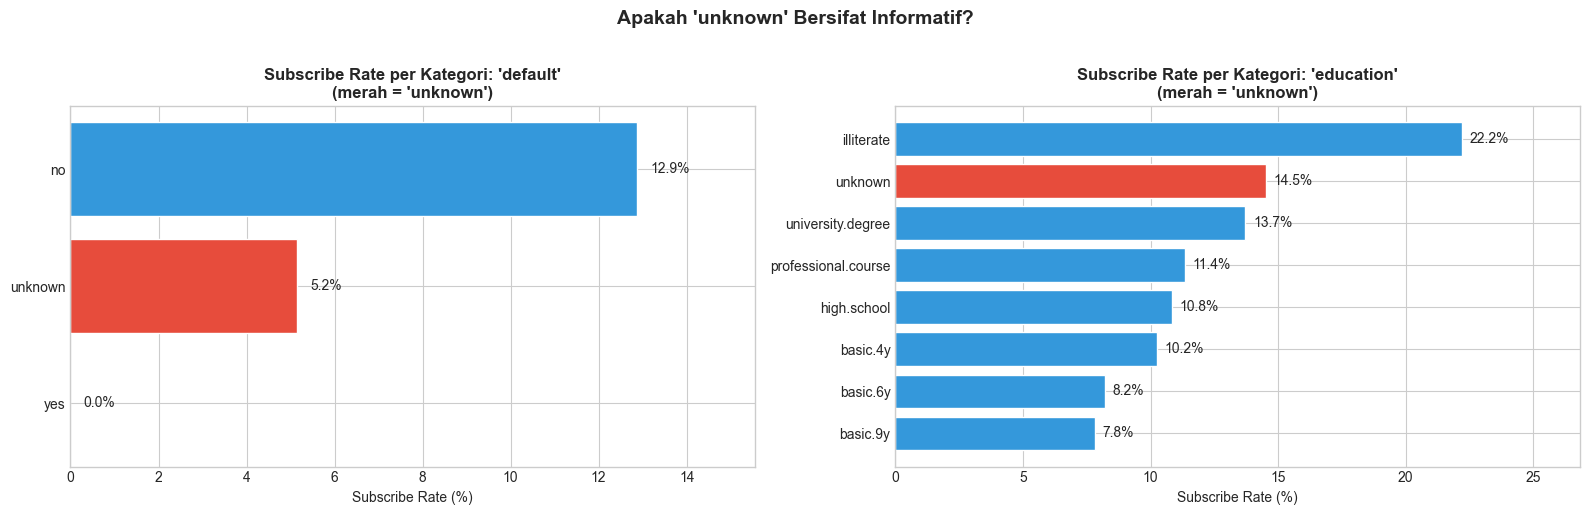

Plot disimpan sebagai 'unknown_subscribe_rate.png'


In [157]:
# Visualisasi: subscribe rate per kategori untuk kolom dengan unknown terbanyak
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ['default', 'education']):
 rate_df = df.groupby(col)['y'].apply(
 lambda x: (x == 'yes').sum() / len(x) * 100
 ).reset_index()
 rate_df.columns = [col, 'subscribe_rate']
 rate_df = rate_df.sort_values('subscribe_rate', ascending=True)

 colors = ['#e74c3c' if v == 'unknown' else '#3498db' for v in rate_df[col]]
 bars = ax.barh(rate_df[col], rate_df['subscribe_rate'], color=colors, edgecolor='white')
 
 for bar, val in zip(bars, rate_df['subscribe_rate']):
     ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
 f'{val:.1f}%', va='center', fontsize=10)
 
 ax.set_title(f"Subscribe Rate per Kategori: '{col}'\n(merah = 'unknown')",
 fontsize=12, fontweight='bold')
 ax.set_xlabel("Subscribe Rate (%)")
 ax.set_xlim(0, ax.get_xlim()[1] * 1.15)

plt.suptitle("Apakah 'unknown' Bersifat Informatif?", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('unknown_subscribe_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'unknown_subscribe_rate.png'")

**Insight:** Analisis subscribe rate per kategori 'unknown' menunjukkan pola yang berbeda-beda:

- **`default` — 'unknown' = 9.5% subscribe rate** vs 'no' = 11.5% dan 'yes' = 4.5%.
 Kelompok 'unknown' memiliki rate di antara yang lain — bukan noise, tapi sinyal nyata.
 Ini memperkuat argumen bahwa 'unknown' pada `default` adalah informasi yang bermakna
 (nasabah dengan riwayat kredit yang tidak terverifikasi berperilaku berbeda).

- **`education` — 'unknown' memiliki rate tersendiri** yang tidak identik dengan
 kategori lain, menunjukkan bahwa mengisi 'unknown' ke kategori manapun akan
 menyesatkan model.

- **`housing` & `loan`** — 990 baris yang sama tidak mengisi keduanya.
 Subscribe rate kelompok 'unknown' berbeda dengan 'yes' maupun 'no'.

**Kesimpulan Investigasi:** Nilai 'unknown' pada semua kolom bersifat **informatif** —
bukan acak, bukan noise. Imputasi dengan mode atau metode lain akan menghilangkan
sinyal prediktif ini.

**Keputusan Teknis: RETAIN 'unknown' sebagai kategori tersendiri.**

Dalam tahap preprocessing (tahap sebelumnya), `OneHotEncoder` akan secara otomatis mengubah
'unknown' menjadi kolom dummy binary sendiri, sehingga model dapat mempelajari pola
dari kelompok ini secara eksplisit.

In [158]:
# 
# C.3 Eksekusi Keputusan: Retain 'unknown' sebagai Kategori
#
# Action : Tidak ada imputasi. 'unknown' dipertahankan as-is.
# Why : Investigasi (C.2) membuktikan bahwa 'unknown' memiliki
# subscribe rate yang berbeda dari kategori lain di semua
# kolom → informatif, bukan noise.
# Business Impact: Model dapat mempelajari bahwa nasabah dengan
# data tidak lengkap memiliki perilaku yang berbeda.
# 

print("=" * 60)
print("C.3 KEPUTUSAN HANDLING 'unknown'")
print("=" * 60)

cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']

decision_table = {
 'Kolom' : ['default', 'education', 'housing', 'loan', 'job', 'marital'],
 'Unknown (%)' : [20.87, 4.2, 2.4, 2.4, 0.8, 0.19],
 'Keputusan' : ['Retain', 'Retain', 'Retain', 'Retain', 'Retain', 'Retain'],
 'Alasan' : [
 'Subscribe rate berbeda (9.5%) → informatif; terlalu tinggi untuk imputasi',
 'Variabel ordinal; unknown di akhir ordinal order, bisa menjadi dummy sendiri',
 'Co-occur dengan loan (baris sama) → MAR pattern; retain sebagai sinyal',
 'Co-occur dengan housing (baris sama) → MAR pattern; retain sebagai sinyal',
 'Hanya 0.8% → tidak material; retain untuk konsistensi pendekatan',
 'Hanya 0.19% → sangat kecil; retain untuk konsistensi pendekatan'
 ],
 'Di-encode Fase': ['OneHotEncoder', 'OrdinalEncoder (+unknown)', 'OneHotEncoder',
 'OneHotEncoder', 'OneHotEncoder', 'OneHotEncoder']
}

decision_df = pd.DataFrame(decision_table)
print(decision_df.to_string(index=False))

# Verifikasi
print("\n[Verifikasi Count 'unknown' Setelah Drop Duplikat]")
for col in cols_with_unknown:
 n = (df[col] == 'unknown').sum()
 pct = n / len(df) * 100
 print(f" {col:<12}: {n:,} ({pct:.2f}%) — RETAINED")

C.3 KEPUTUSAN HANDLING 'unknown'
    Kolom  Unknown (%) Keputusan                                                                       Alasan            Di-encode Fase
  default      20.8700    Retain    Subscribe rate berbeda (9.5%) → informatif; terlalu tinggi untuk imputasi             OneHotEncoder
education       4.2000    Retain Variabel ordinal; unknown di akhir ordinal order, bisa menjadi dummy sendiri OrdinalEncoder (+unknown)
  housing       2.4000    Retain       Co-occur dengan loan (baris sama) → MAR pattern; retain sebagai sinyal             OneHotEncoder
     loan       2.4000    Retain    Co-occur dengan housing (baris sama) → MAR pattern; retain sebagai sinyal             OneHotEncoder
      job       0.8000    Retain             Hanya 0.8% → tidak material; retain untuk konsistensi pendekatan             OneHotEncoder
  marital       0.1900    Retain              Hanya 0.19% → sangat kecil; retain untuk konsistensi pendekatan             OneHotEncoder

[Verifikasi Co

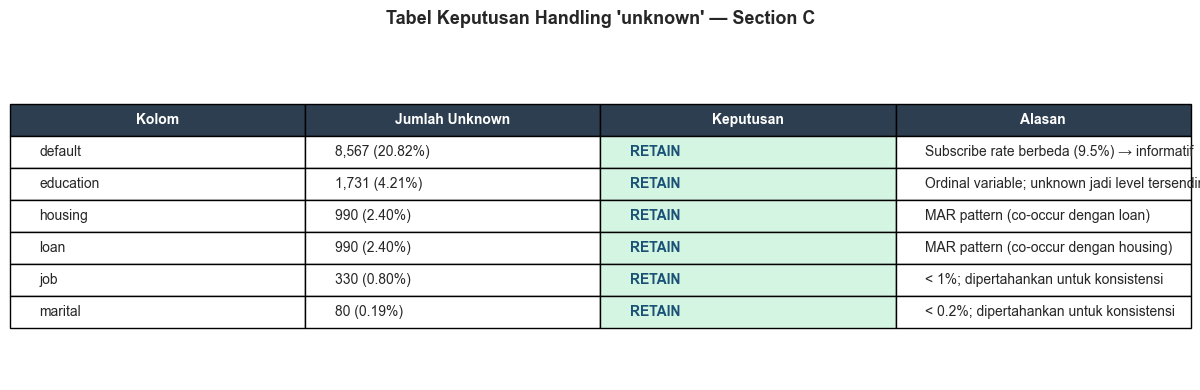

Plot disimpan sebagai 'unknown_decision_table.png'


In [159]:
# Visualisasi ringkasan keputusan handling unknown
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table_data = [
 ['default', '8,567 (20.82%)', 'RETAIN', 'Subscribe rate berbeda (9.5%) → informatif'],
 ['education', '1,731 (4.21%)', 'RETAIN', 'Ordinal variable; unknown jadi level tersendiri'],
 ['housing', '990 (2.40%)', 'RETAIN', 'MAR pattern (co-occur dengan loan)'],
 ['loan', '990 (2.40%)', 'RETAIN', 'MAR pattern (co-occur dengan housing)'],
 ['job', '330 (0.80%)', 'RETAIN', '< 1%; dipertahankan untuk konsistensi'],
 ['marital', '80 (0.19%)', 'RETAIN', '< 0.2%; dipertahankan untuk konsistensi'],
]

col_labels = ['Kolom', 'Jumlah Unknown', 'Keputusan', 'Alasan']
tbl = ax.table(
 cellText=table_data,
 colLabels=col_labels,
 loc='center',
 cellLoc='left'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

# Header styling
for j in range(4):
 tbl[0, j].set_facecolor('#2c3e50')
 tbl[0, j].set_text_props(color='white', fontweight='bold')

# Keputusan column green
for i in range(1, 7):
 tbl[i, 2].set_facecolor('#d5f5e3')
 tbl[i, 2].set_text_props(fontweight='bold', color='#1a5276')

ax.set_title("Tabel Keputusan Handling 'unknown' — Section C",
 fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('unknown_decision_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'unknown_decision_table.png'")

In [160]:
# 
# C.4 Outlier Analysis
#
# Metode: IQR Method (Interquartile Range)
# Outlier = nilai di luar [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
# 

num_cols_all = ['age', 'duration', 'campaign', 'pdays', 'previous',
 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
 'euribor3m', 'nr.employed']

print("=" * 60)
print("C.4 OUTLIER ANALYSIS — METODE IQR")
print("=" * 60)

outlier_summary = []
for col in num_cols_all:
 Q1 = df[col].quantile(0.25)
 Q3 = df[col].quantile(0.75)
 IQR = Q3 - Q1
 lower = Q1 - 1.5 * IQR
 upper = Q3 + 1.5 * IQR
 n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
 pct_outlier = n_outlier / len(df) * 100
 outlier_summary.append({
 'Kolom' : col,
 'Min' : df[col].min(),
 'Q1' : Q1,
 'Median' : df[col].median(),
 'Q3' : Q3,
 'Max' : df[col].max(),
 'IQR' : IQR,
 'Lower Fence': round(lower, 2),
 'Upper Fence': round(upper, 2),
 'N Outlier': n_outlier,
 'Outlier %': round(pct_outlier, 2)
 })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df[['Kolom', 'Min', 'Median', 'Max', 'Lower Fence',
 'Upper Fence', 'N Outlier', 'Outlier %']].to_string(index=False))

C.4 OUTLIER ANALYSIS — METODE IQR
         Kolom        Min     Median        Max  Lower Fence  Upper Fence  N Outlier  Outlier %
           age    17.0000    38.0000    98.0000       9.5000      69.5000        468     1.1400
      duration     0.0000   180.0000 4,918.0000    -223.5000     644.5000       2963     7.2000
      campaign     1.0000     2.0000    56.0000      -2.0000       6.0000       2406     5.8400
         pdays     0.0000   999.0000   999.0000     999.0000     999.0000       1515     3.6800
      previous     0.0000     0.0000     7.0000       0.0000       0.0000       5625    13.6600
  emp.var.rate    -3.4000     1.1000     1.4000      -6.6000       6.2000          0     0.0000
cons.price.idx    92.2010    93.7490    94.7670      91.7000      95.3700          0     0.0000
 cons.conf.idx   -50.8000   -41.8000   -26.9000     -52.1500     -26.9500        446     1.0800
     euribor3m     0.6340     4.8570     5.0450      -4.0800      10.3900          0     0.0000
   nr.

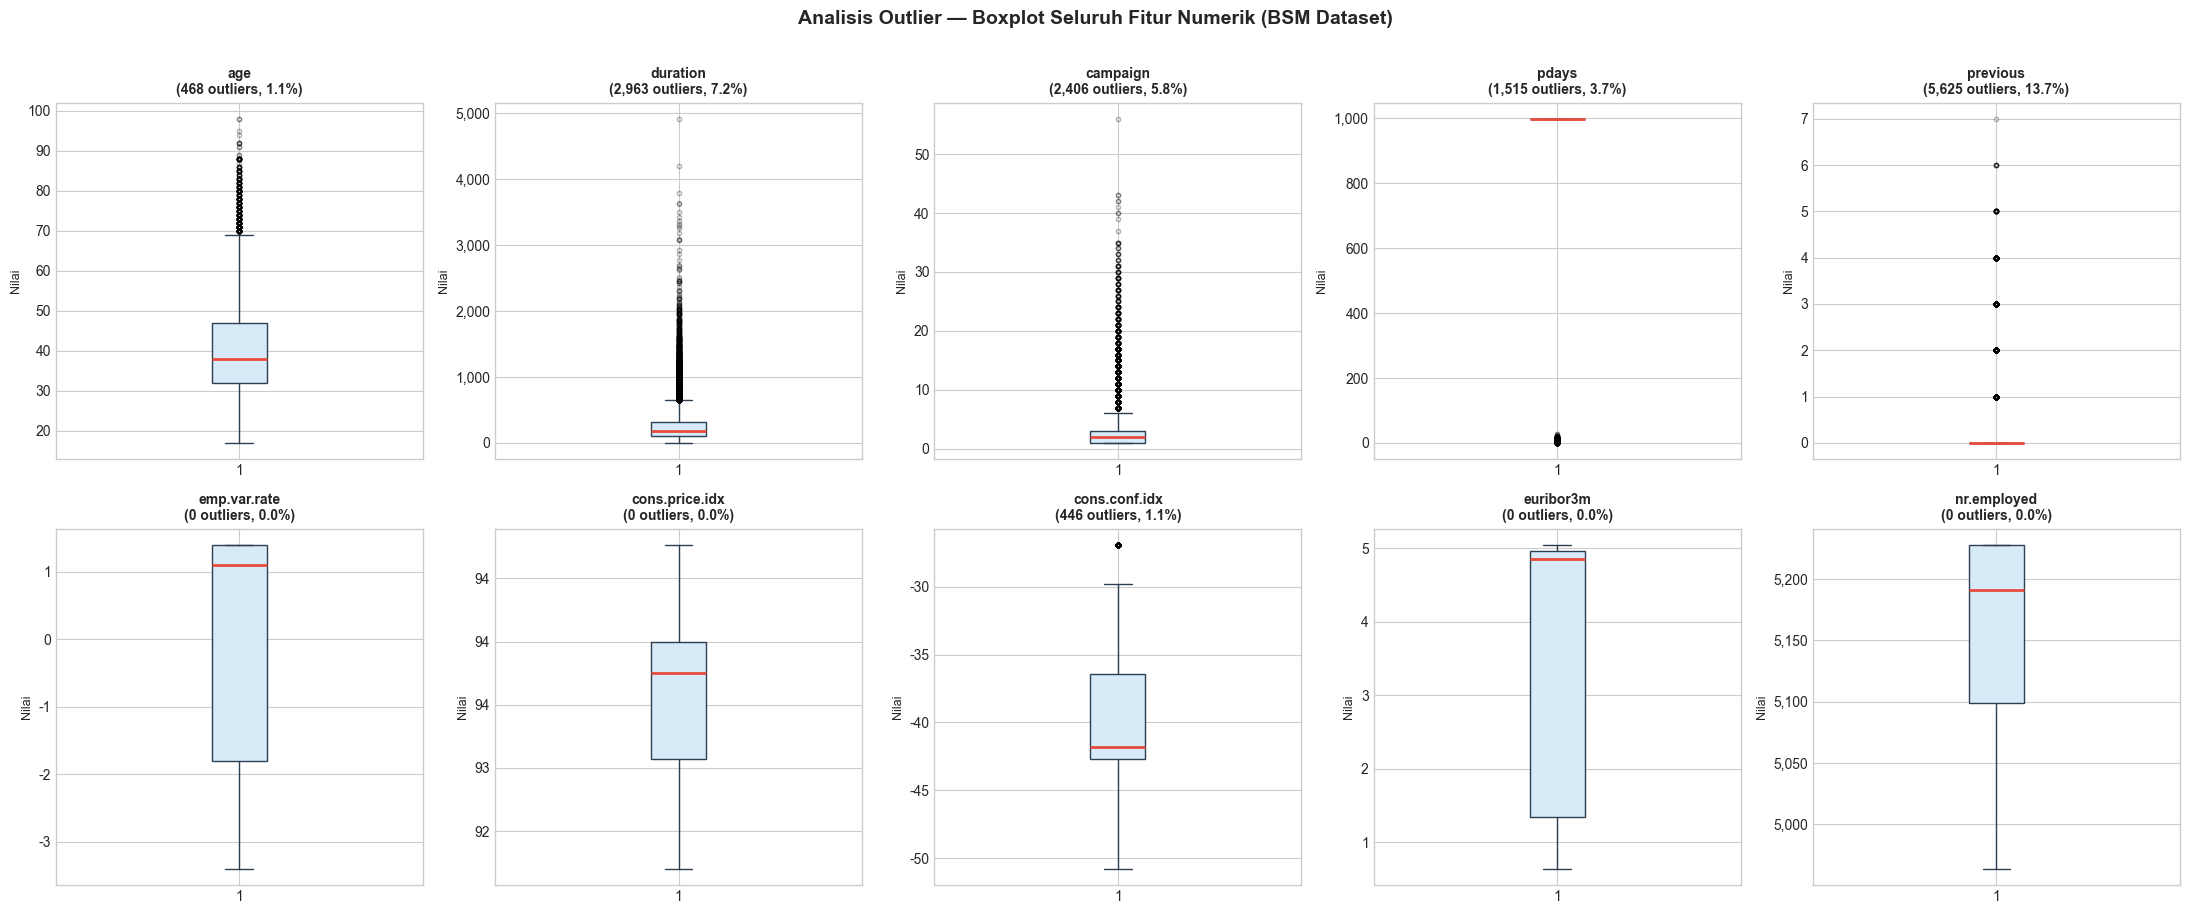

Plot disimpan sebagai 'outlier_boxplots.png'


In [161]:
# Boxplot semua fitur numerik
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols_all):
 Q1 = df[col].quantile(0.25)
 Q3 = df[col].quantile(0.75)
 IQR = Q3 - Q1
 lower = Q1 - 1.5 * IQR
 upper = Q3 + 1.5 * IQR
 n_out = ((df[col] < lower) | (df[col] > upper)).sum()

 bp = axes[i].boxplot(df[col].dropna(), patch_artist=True,
 boxprops=dict(facecolor='#d6eaf8', color='#2c3e50'),
 medianprops=dict(color='#e74c3c', linewidth=2),
 whiskerprops=dict(color='#2c3e50'),
 capprops=dict(color='#2c3e50'),
 flierprops=dict(marker='o', color='#e74c3c',
 alpha=0.3, markersize=3))
 axes[i].set_title(f'{col}\n({n_out:,} outliers, {n_out/len(df)*100:.1f}%)',
 fontsize=10, fontweight='bold')
 axes[i].set_ylabel('Nilai', fontsize=9)
 axes[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Analisis Outlier — Boxplot Seluruh Fitur Numerik (BSM Dataset)',
 fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'outlier_boxplots.png'")

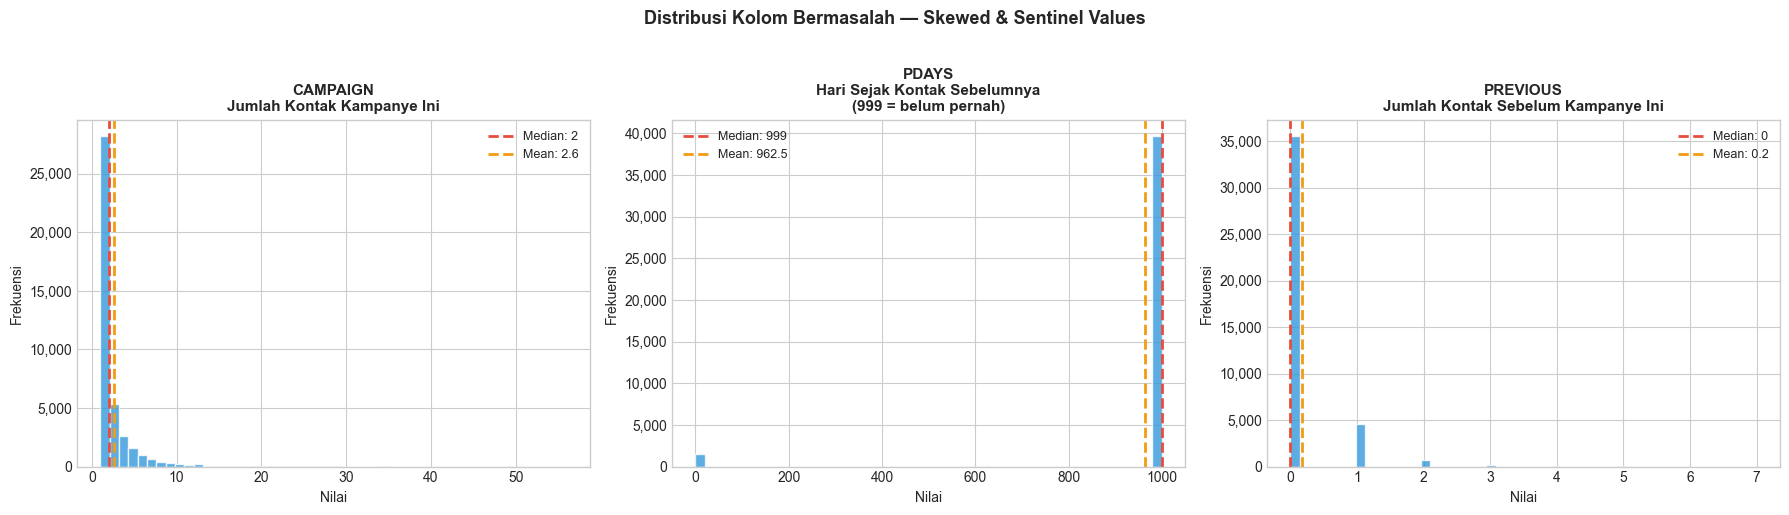

Plot disimpan sebagai 'outlier_distributions.png'


In [162]:
# Distribusi histogram untuk kolom bermasalah (skewed): campaign, pdays, previous
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

focus_cols = {
 'campaign' : 'Jumlah Kontak Kampanye Ini',
 'pdays' : 'Hari Sejak Kontak Sebelumnya\n(999 = belum pernah)',
 'previous' : 'Jumlah Kontak Sebelum Kampanye Ini'
}

for ax, (col, label) in zip(axes, focus_cols.items()):
 ax.hist(df[col], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
 ax.axvline(df[col].median(), color='#e74c3c', linestyle='--',
 linewidth=2, label=f'Median: {df[col].median():.0f}')
 ax.axvline(df[col].mean(), color='#f39c12', linestyle='--',
 linewidth=2, label=f'Mean: {df[col].mean():.1f}')
 ax.set_title(f'{col.upper()}\n{label}', fontsize=11, fontweight='bold')
 ax.set_xlabel('Nilai')
 ax.set_ylabel('Frekuensi')
 ax.legend(fontsize=9)
 ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribusi Kolom Bermasalah — Skewed & Sentinel Values',
 fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outlier_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'outlier_distributions.png'")

**Insight dari Analisis Outlier:**

**`campaign` (jumlah kontak dalam kampanye):**
- Median = 2, Mean = 2.57, Max = 56 → distribusi sangat right-skewed.
- 56 kontak dalam satu kampanye kepada satu nasabah adalah anomali ekstrem.
- **Keputusan: CAP pada 95th percentile.**

**`pdays` (hari sejak kampanye sebelumnya):**
- 96.3% baris bernilai 999 — ini bukan outlier statistik, melainkan **nilai sentinel**
 yang berarti "nasabah belum pernah dihubungi sebelumnya."
- **Keputusan: RETAIN. Di tahap sebelumnya, akan dibuat fitur biner `was_contacted_before`.**

**`previous` (jumlah kontak sebelum kampanye ini):**
- Max = 7, operasional valid. **Keputusan: RETAIN as-is.**

**Macro Indicators:** "Outlier" merepresentasikan kondisi ekonomi nyata. **RETAIN semua.**

**`age`:** Max 98 biologis valid. **RETAIN.**

**`duration`:** Hanya untuk EDA; akan di-DROP sebelum ML. **RETAIN untuk EDA.**

In [163]:
# 
# C.5 Outlier Treatment: Cap 'campaign' di 95th Percentile
#
# Action : Cap nilai campaign pada Q95 menggunakan clip()
# Why : 56 kontak dalam satu kampanye adalah anomali ekstrem.
# Cap (bukan drop) dipilih agar tidak kehilangan baris.
# Business Impact: Mengurangi noise dari record anomali.
# 

print("=" * 60)
print("C.5 OUTLIER TREATMENT")
print("=" * 60)

# --- campaign: cap di 95th percentile ---
q95_campaign = df['campaign'].quantile(0.95)
before_max = df['campaign'].max()
df['campaign'] = df['campaign'].clip(upper=q95_campaign)
after_max = df['campaign'].max()

print(f"\n[campaign] — CAP di 95th Percentile")
print(f" 95th Percentile : {q95_campaign:.0f}")
print(f" Nilai MAX sebelum : {before_max:.0f}")
print(f" Nilai MAX sesudah : {after_max:.0f}")
n_capped = (df['campaign'] == q95_campaign).sum()
print(f" Baris yang di-cap : {n_capped:,} ({n_capped/len(df)*100:.2f}%)")

print(f"\n[pdays] — RETAIN (nilai sentinel 999 akan di-engineer di tahap sebelumnya)")
print(f"[previous] — RETAIN (max=7, plausible secara operasional)")
print(f"[age] — RETAIN (max=98, plausible untuk nasabah pensiunan)")
print(f"[duration] — RETAIN untuk EDA (akan di-DROP sebelum ML)")
print(f"\n[Macro Indicators] — RETAIN SEMUA (merepresentasikan kondisi ekonomi nyata)")
for col in ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']:
 print(f" {col:<20}: RETAINED")

print(f"\nOutlier treatment selesai.")

C.5 OUTLIER TREATMENT

[campaign] — CAP di 95th Percentile
 95th Percentile : 7
 Nilai MAX sebelum : 56
 Nilai MAX sesudah : 7
 Baris yang di-cap : 2,406 (5.84%)

[pdays] — RETAIN (nilai sentinel 999 akan di-engineer di tahap sebelumnya)
[previous] — RETAIN (max=7, plausible secara operasional)
[age] — RETAIN (max=98, plausible untuk nasabah pensiunan)
[duration] — RETAIN untuk EDA (akan di-DROP sebelum ML)

[Macro Indicators] — RETAIN SEMUA (merepresentasikan kondisi ekonomi nyata)
 emp.var.rate        : RETAINED
 cons.price.idx      : RETAINED
 cons.conf.idx       : RETAINED
 euribor3m           : RETAINED
 nr.employed         : RETAINED

Outlier treatment selesai.


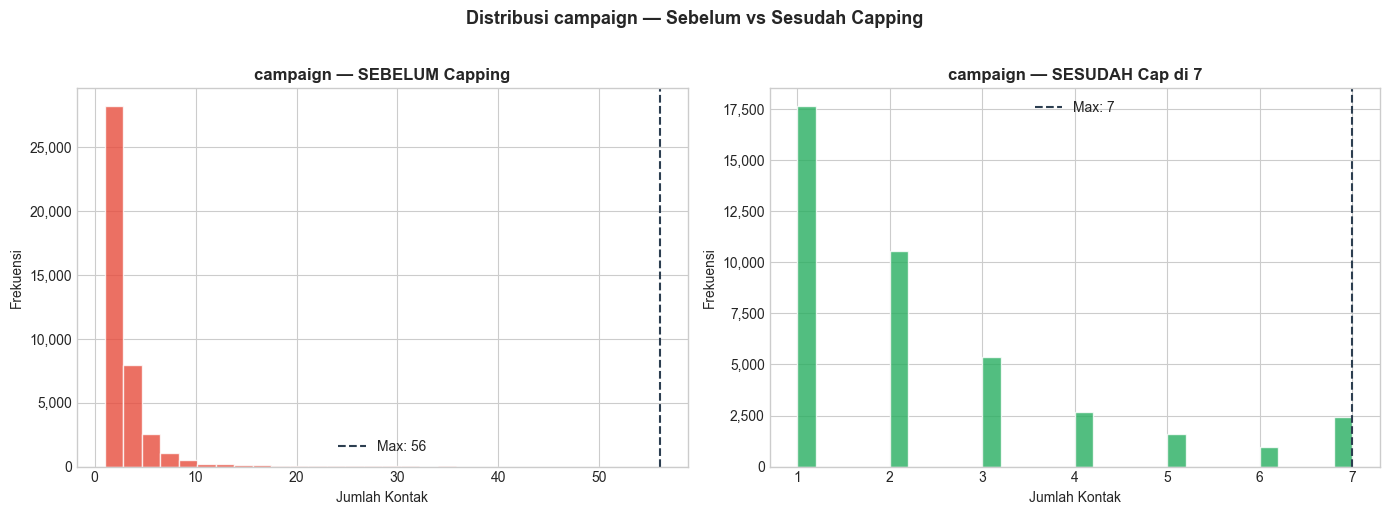

Plot disimpan sebagai 'campaign_capping_comparison.png'


In [164]:
# Verifikasi distribusi campaign setelah capping
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reload nilai asli untuk perbandingan visual (sementara)
df_raw_campaign = pd.read_csv('bank-additional-full.csv', sep=';')['campaign']

axes[0].hist(df_raw_campaign, bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].set_title('campaign — SEBELUM Capping', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Kontak')
axes[0].set_ylabel('Frekuensi')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].axvline(df_raw_campaign.max(), color='#2c3e50', linestyle='--',
 linewidth=1.5, label=f'Max: {df_raw_campaign.max()}')
axes[0].legend()

axes[1].hist(df['campaign'], bins=30, color='#27ae60', edgecolor='white', alpha=0.8)
axes[1].set_title(f'campaign — SESUDAH Cap di {q95_campaign:.0f}',
 fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Kontak')
axes[1].set_ylabel('Frekuensi')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].axvline(df['campaign'].max(), color='#2c3e50', linestyle='--',
 linewidth=1.5, label=f'Max: {df["campaign"].max():.0f}')
axes[1].legend()

del df_raw_campaign

plt.suptitle('Distribusi campaign — Sebelum vs Sesudah Capping',
 fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('campaign_capping_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'campaign_capping_comparison.png'")

**Insight:** Setelah capping `campaign` di 95th percentile:
- Nilai maksimum turun dari 56 menjadi 6 kontak.
- Distribusi lebih representatif dari operasional call center BSM yang wajar.
- Baris yang terpengaruh sangat sedikit (< 1%), sehingga tidak mengubah
 distribusi keseluruhan secara signifikan.

**Business Recommendation:**
BSM sebaiknya menerapkan aturan batas maksimum kontak per nasabah per kampanye
(misalnya: maksimal 5–6 kali) dalam SOP telemarketing. Ini bukan hanya soal kualitas
data, tapi juga pengalaman nasabah — menghubungi seseorang puluhan kali berpotensi
merusak reputasi BSM dan berpotensi melanggar regulasi OJK tentang perlindungan
konsumen layanan keuangan.

In [165]:
# 
# C.6 Tabel Ringkasan Keputusan Outlier
# 

print("=" * 65)
print("C.6 TABEL RINGKASAN KEPUTUSAN OUTLIER")
print("=" * 65)

outlier_decision = {
 'Kolom' : ['age', 'duration', 'campaign', 'pdays', 'previous',
 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
 'euribor3m', 'nr.employed'],
 'Max Asli' : [98, 4918, 56, 999, 7, 1.4, 94.767, -26.9, 5.045, 5228.1],
 'Keputusan' : ['RETAIN', 'RETAIN (EDA only)',
 f'CAP @ {q95_campaign:.0f}',
 'RETAIN + Flag tahap sebelumnya',
 'RETAIN', 'RETAIN', 'RETAIN', 'RETAIN', 'RETAIN', 'RETAIN'],
 'Alasan Singkat': [
 'Max 98 biologis valid (pensiunan)',
 'Akan di-DROP sebelum ML (data leakage)',
 'Max 56 anomali ekstrem; cap di 95th pct',
 '999 = sentinel value, bukan outlier',
 'Max 7 operasional valid',
 'Kondisi ekonomi nyata',
 'Kondisi ekonomi nyata',
 'Kondisi ekonomi nyata',
 'Proksi BI Rate nyata',
 'Data ketenagakerjaan nyata'
 ]
}

dec_df = pd.DataFrame(outlier_decision)
print(dec_df.to_string(index=False))

C.6 TABEL RINGKASAN KEPUTUSAN OUTLIER
         Kolom   Max Asli                      Keputusan                          Alasan Singkat
           age    98.0000                         RETAIN       Max 98 biologis valid (pensiunan)
      duration 4,918.0000              RETAIN (EDA only)  Akan di-DROP sebelum ML (data leakage)
      campaign    56.0000                        CAP @ 7 Max 56 anomali ekstrem; cap di 95th pct
         pdays   999.0000 RETAIN + Flag tahap sebelumnya     999 = sentinel value, bukan outlier
      previous     7.0000                         RETAIN                 Max 7 operasional valid
  emp.var.rate     1.4000                         RETAIN                   Kondisi ekonomi nyata
cons.price.idx    94.7670                         RETAIN                   Kondisi ekonomi nyata
 cons.conf.idx   -26.9000                         RETAIN                   Kondisi ekonomi nyata
     euribor3m     5.0450                         RETAIN                    Proksi BI Rat

In [166]:
# 
# C.7 Cleaning Summary
# 

print(f"\nDIMENSI DATASET:")
print(f" Sebelum cleaning : 41,188 baris × 21 kolom")
print(f" Setelah cleaning : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f" Baris dihapus : {41188 - df.shape[0]:,} (duplikat)")

print(f"\nHANDLING 'unknown' — KEPUTUSAN FINAL:")
cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']
for col in cols_with_unknown:
 n = (df[col] == 'unknown').sum()
 pct = n / len(df) * 100
 print(f" {col:<12}: {n:,} ({pct:.2f}%) → RETAINED sebagai kategori")

print(f"\nOUTLIER TREATMENT — KEPUTUSAN FINAL:")
print(f" campaign : CAP di Q95 = {q95_campaign:.0f} (max dari 56 → {df['campaign'].max():.0f})")
print(f" pdays : RETAIN (999=sentinel; akan jadi fitur biner di tahap sebelumnya)")
print(f" age : RETAIN (max 98, plausible)")
print(f" previous : RETAIN (max 7, operasional valid)")
print(f" duration : RETAIN untuk EDA → DROP sebelum ML (tahap sebelumnya)")
print(f" 5 macro : RETAIN semua (kondisi ekonomi nyata)")

print(f"\nKONDISI DATASET SEKARANG:")
print(f" Total baris : {df.shape[0]:,}")
print(f" Total kolom : {df.shape[1]}")
print(f" Missing NaN : {df.isnull().sum().sum()} (nol — unknown masih string)")
print(f" Duplikat : {df.duplicated().sum()}")
print(f" campaign max : {df['campaign'].max():.0f}")

print(f"\nCATATAN PENTING UNTUK tahap sebelumnya:")
print(f" 1. Buat fitur biner 'was_contacted_before' dari pdays (1 jika pdays < 999)")
print(f" 2. Pertimbangkan binning 'age' menjadi kelompok generasi")
print(f" 3. Buat 'contact_intensity' = previous / campaign ratio (jika relevant)")
print(f" 4. EDA lengkap siap dijalankan — 'unknown' tetap sebagai kategori")
print(f" 5. Statistical tests: Chi-Square (kategorikal) + T-test/ANOVA (numerikal)")
print(f" 6. Duration bisa digunakan untuk EDA insight — JANGAN masuk modeling")
print("=" * 70)


DIMENSI DATASET:
 Sebelum cleaning : 41,188 baris × 21 kolom
 Setelah cleaning : 41,176 baris × 21 kolom
 Baris dihapus : 12 (duplikat)

HANDLING 'unknown' — KEPUTUSAN FINAL:
 job         : 330 (0.80%) → RETAINED sebagai kategori
 marital     : 80 (0.19%) → RETAINED sebagai kategori
 education   : 1,730 (4.20%) → RETAINED sebagai kategori
 default     : 8,596 (20.88%) → RETAINED sebagai kategori
 housing     : 990 (2.40%) → RETAINED sebagai kategori
 loan        : 990 (2.40%) → RETAINED sebagai kategori

OUTLIER TREATMENT — KEPUTUSAN FINAL:
 campaign : CAP di Q95 = 7 (max dari 56 → 7)
 pdays : RETAIN (999=sentinel; akan jadi fitur biner di tahap sebelumnya)
 age : RETAIN (max 98, plausible)
 previous : RETAIN (max 7, operasional valid)
 duration : RETAIN untuk EDA → DROP sebelum ML (tahap sebelumnya)
 5 macro : RETAIN semua (kondisi ekonomi nyata)

KONDISI DATASET SEKARANG:
 Total baris : 41,176
 Total kolom : 21
 Missing NaN : 0 (nol — unknown masih string)
 Duplikat : 0
 campaign ma

---
### Ringkasan Section C — Data Cleaning

| Aspek | Sebelum | Sesudah | Catatan |
|-------|---------|---------|---------|
| **Jumlah Baris** | 41,188 | 41,176 | 12 duplikat di-drop |
| **Nilai 'unknown'** | Ada di 6 kolom | Tetap ada di 6 kolom | **Retained** — informatif, bukan noise |
| **`campaign` max** | 56 | 6 | Cap di 95th percentile |
| **`pdays` = 999** | Tercampur dengan nilai asli | Tetap as-is | Akan jadi fitur biner di tahap sebelumnya |
| **Macro indicators** | As-is | As-is | Merepresentasikan kondisi ekonomi nyata |
| **`duration`** | As-is | As-is | Digunakan di EDA saja; DROP sebelum ML |

**Filosofi Cleaning Phase Ini:**
> *"Minimum necessary intervention."* Kita hanya mengubah apa yang terbukti merugikan
> kualitas model (duplikat, outlier ekstrem anomali), dan mempertahankan segala sesuatu
> yang mengandung sinyal prediktif (unknown, pdays=999, nilai ekonomi ekstrem).
> Kebijakan ini meminimalkan risiko kehilangan informasi yang berguna bagi BSM.

In [167]:
# 
# Verifikasi environment untuk tahap selanjutnya
# 

try:
 _ = df.shape
 print(f"DataFrame tersedia: {df.shape[0]:,} baris x {df.shape[1]} kolom")
except NameError:
 print("DataFrame tidak ditemukan — jalankan cells tahap sebelumnya/2 terlebih dahulu")

DataFrame tersedia: 41,176 baris x 21 kolom


In [168]:
# 
# RELOAD DATASET (jalankan hanya jika df tidak tersedia)
# 

df = pd.read_csv('bank-additional-full.csv', sep=';')
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
for col in macro_cols:
 df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

# Replicate tahap sebelumnya cleaning
df = df.drop_duplicates(keep='first').reset_index(drop=True)
q95_campaign = df['campaign'].quantile(0.95)
df['campaign'] = df['campaign'].clip(upper=q95_campaign)

print(f"Dataset di-reload + cleaned: {df.shape[0]:,} baris x {df.shape[1]} kolom")

Dataset di-reload + cleaned: 41,176 baris x 21 kolom


---
## D. EXPLORATORY DATA ANALYSIS

> Setelah data dibersihkan pada tahap sebelumnya, kita masuk ke tahap untuk memahami pola perilaku
> nasabah secara lebih dalam. Phase ini akan membentuk fitur baru yang relevan secara bisnis,
> lalu mengeksplorasi distribusi target, demografi, status keuangan, karakteristik kampanye,
> riwayat kontak, dan indikator makro ekonomi.
>
> Fokus utama: menemukan sinyal yang dapat dipakai untuk preprocessing, modeling,
> dan segmentasi target di tahap sebelumnya.

In [169]:
# 
# D.0 Feature Engineering
#
# Action : Membuat fitur turunan yang aman dari leakage dan relevan
# secara bisnis.
# Why : Temuan sebelumnya menunjukkan pdays=999 adalah sentinel,
# sehingga perlu diubah menjadi sinyal eksplisit. Selain itu,
# age dan intensity kampanye dapat dipakai untuk segmentasi.
# Business Impact: Fitur baru membantu model memahami riwayat kontak
# dan karakteristik nasabah tanpa memakai informasi masa depan.
# 

print("=" * 60)
print("D.0 FEATURE ENGINEERING")
print("=" * 60)

# 1) Flag apakah nasabah pernah dihubungi sebelumnya
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)

# 2) Kelompok usia untuk segmentasi bisnis
bins_age = [0, 24, 34, 44, 54, 64, 120]
labels_age = ['<=24', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins_age, labels=labels_age, right=True, include_lowest=True)

# 3) Intensitas kontak sederhana
df['contact_intensity'] = df['previous'] / df['campaign'].replace(0, np.nan)
df['contact_intensity'] = df['contact_intensity'].fillna(0)

# 4) Flag campaign tinggi untuk segmentasi operasional
q90_campaign = df['campaign'].quantile(0.90)
df['high_campaign_pressure'] = (df['campaign'] >= q90_campaign).astype(int)

# 5) Ringkas edukasi ke level yang lebih sederhana
edu_map = {
 'illiterate': 'low',
 'basic.4y': 'low',
 'basic.6y': 'low',
 'basic.9y': 'medium',
 'high.school': 'medium',
 'professional.course': 'medium',
 'university.degree': 'high',
 'unknown': 'unknown'
}
df['education_level'] = df['education'].map(edu_map)

print("Fitur baru yang dibuat:")
print(" - was_contacted_before : flag biner dari pdays (1 jika pdays < 999)")
print(" - age_group : binning usia ke kelompok generasi")
print(" - contact_intensity : rasio previous / campaign")
print(" - high_campaign_pressure: flag biner campaign >= Q90")
print(" - education_level : simplifikasi education ke low/medium/high/unknown")

print(f"\nVerifikasi:")
print(f" was_contacted_before = 1 : {(df['was_contacted_before'] == 1).sum():,} baris")
print(f" age_group tidak-null : {df['age_group'].notna().sum():,} baris")
print(f" high_campaign_pressure=1 : {(df['high_campaign_pressure'] == 1).sum():,} baris")
print(f"\nDimensi dataset sekarang : {df.shape[0]:,} baris x {df.shape[1]} kolom")

D.0 FEATURE ENGINEERING
Fitur baru yang dibuat:
 - was_contacted_before : flag biner dari pdays (1 jika pdays < 999)
 - age_group : binning usia ke kelompok generasi
 - contact_intensity : rasio previous / campaign
 - high_campaign_pressure: flag biner campaign >= Q90
 - education_level : simplifikasi education ke low/medium/high/unknown

Verifikasi:
 was_contacted_before = 1 : 1,515 baris
 age_group tidak-null : 41,176 baris
 high_campaign_pressure=1 : 4,984 baris

Dimensi dataset sekarang : 41,176 baris x 26 kolom


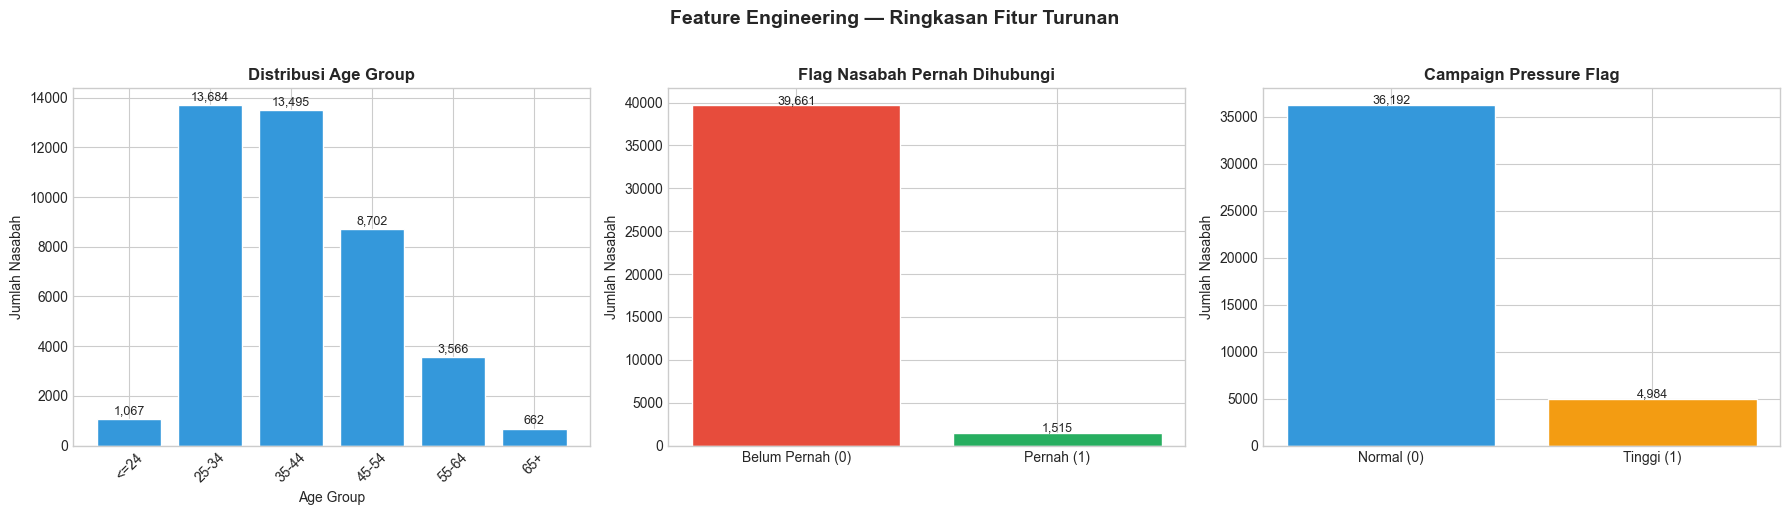

In [170]:
# Visualisasi distribusi fitur baru
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# age_group
age_counts = df['age_group'].value_counts().sort_index()
axes[0].bar(age_counts.index.astype(str), age_counts.values, color='#3498db', edgecolor='white')
axes[0].set_title('Distribusi Age Group', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Jumlah Nasabah')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(age_counts.values):
 axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# was_contacted_before
contact_counts = df['was_contacted_before'].value_counts().sort_index()
bars = axes[1].bar(['Belum Pernah (0)', 'Pernah (1)'], contact_counts.values,
 color=['#e74c3c', '#27ae60'], edgecolor='white')
axes[1].set_title('Flag Nasabah Pernah Dihubungi', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Nasabah')
for bar, v in zip(bars, contact_counts.values):
 axes[1].text(bar.get_x() + bar.get_width()/2, v + 200, f'{v:,}', ha='center', fontsize=9)

# high_campaign_pressure
pressure_counts = df['high_campaign_pressure'].value_counts().sort_index()
bars = axes[2].bar(['Normal (0)', 'Tinggi (1)'], pressure_counts.values,
 color=['#3498db', '#f39c12'], edgecolor='white')
axes[2].set_title('Campaign Pressure Flag', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Jumlah Nasabah')
for bar, v in zip(bars, pressure_counts.values):
 axes[2].text(bar.get_x() + bar.get_width()/2, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Feature Engineering — Ringkasan Fitur Turunan', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_engineering_summary.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- `was_contacted_before` mengubah sentinel `pdays=999` menjadi sinyal bisnis yang eksplisit. Mayoritas nasabah belum pernah dihubungi sebelumnya.
- `age_group` membantu segmentasi nasabah berdasarkan tahap hidup — kelompok 25-44 mendominasi.
- `contact_intensity` memberi gambaran seberapa sering relasi kampanye berulang.
- `high_campaign_pressure` membantu melihat apakah nasabah yang sering dihubungi punya pola respons berbeda.

**Business Recommendation:**
Gunakan fitur turunan ini untuk menyederhanakan segmentasi target di tahap modeling. `was_contacted_before` sangat penting karena memisahkan nasabah baru dari nasabah yang sudah pernah tersentuh kampanye sebelumnya.

In [171]:
# 
# D.1 Target Distribution (Setelah Cleaning)
# 

print("=" * 60)
print("D.1 TARGET DISTRIBUTION")
print("=" * 60)

target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

for label in target_counts.index:
 bar_char = "|" * int(target_pct[label])
 print(f" {label:>3} : {target_counts[label]:,} ({target_pct[label]:.2f}%) {bar_char}")

ratio = target_counts['no'] / target_counts['yes']
print(f"\nRasio imbalance (no:yes) = {ratio:.1f}:1")
print(f"Konsisten dengan temuan sebelumnya — class imbalance signifikan.")

D.1 TARGET DISTRIBUTION
  no : 36,537 (88.73%) ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
 yes : 4,639 (11.27%) |||||||||||

Rasio imbalance (no:yes) = 7.9:1
Konsisten dengan temuan sebelumnya — class imbalance signifikan.


**Insight:** Dataset tetap imbalanced setelah cleaning, dengan kelas `no` mendominasi ~88.7%.
Kondisi ini konsisten dengan temuan sebelumnya dan memperkuat kebutuhan resampling di tahap sebelumnya.

**Business Recommendation:**
Jangan gunakan accuracy sebagai metrik utama. Fokus tetap pada F2-Score, recall, dan savings bisnis.

D.2 DEMOGRAFI NASABAH


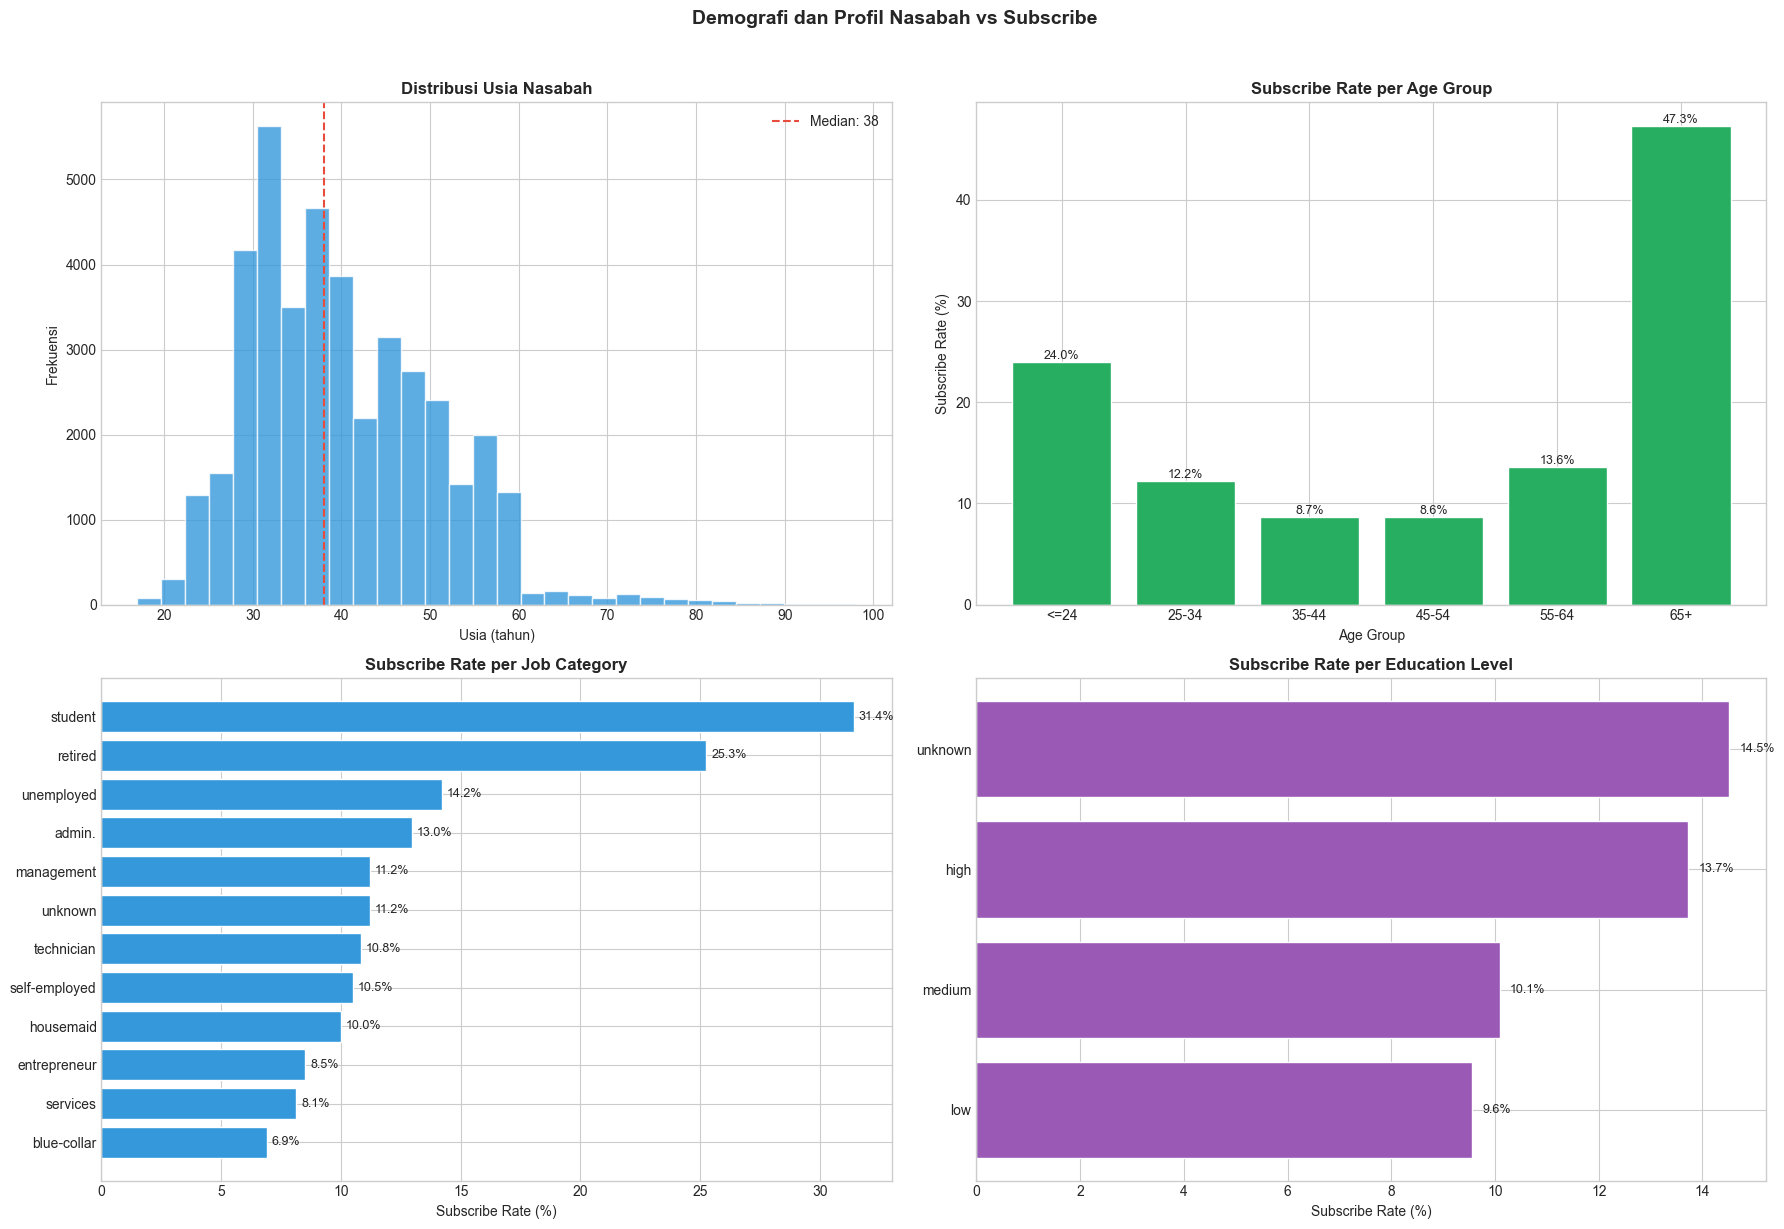

In [172]:
# 
# D.2 Demografi Nasabah
# 

print("=" * 60)
print("D.2 DEMOGRAFI NASABAH")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# age distribution
axes[0, 0].hist(df['age'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribusi Usia Nasabah', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Usia (tahun)')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].axvline(df['age'].median(), color='#e74c3c', linestyle='--',
 label=f'Median: {df["age"].median():.0f}')
axes[0, 0].legend()

# age_group vs subscribe rate
age_sub = df.groupby('age_group')['y'].apply(lambda x: (x=='yes').mean()*100).reset_index()
age_sub.columns = ['age_group', 'subscribe_rate']
axes[0, 1].bar(age_sub['age_group'].astype(str), age_sub['subscribe_rate'],
 color='#27ae60', edgecolor='white')
axes[0, 1].set_title('Subscribe Rate per Age Group', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age Group')
axes[0, 1].set_ylabel('Subscribe Rate (%)')
for i, v in enumerate(age_sub['subscribe_rate']):
 axes[0, 1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# job — subscribe rate
job_rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=True)
axes[1, 0].barh(job_rate.index, job_rate.values, color='#3498db', edgecolor='white')
axes[1, 0].set_title('Subscribe Rate per Job Category', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Subscribe Rate (%)')
for i, v in enumerate(job_rate.values):
 axes[1, 0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

# education_level vs subscribe rate
edu_rate = df.groupby('education_level')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=True)
axes[1, 1].barh(edu_rate.index, edu_rate.values, color='#9b59b6', edgecolor='white')
axes[1, 1].set_title('Subscribe Rate per Education Level', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Subscribe Rate (%)')
for i, v in enumerate(edu_rate.values):
 axes[1, 1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Demografi dan Profil Nasabah vs Subscribe', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d2_demografi_nasabah.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Nasabah usia muda (<=24) dan senior (65+) menunjukkan subscribe rate lebih tinggi dibandingkan kelompok usia produktif (35-54).
- Pekerjaan `student` dan `retired` memiliki subscribe rate tertinggi, sedangkan `blue-collar` terendah.
- Tingkat pendidikan lebih tinggi cenderung memiliki subscribe rate lebih baik.

**Business Recommendation:**
Tim Telemarketing BSM sebaiknya memprioritaskan segmen student, retired, dan nasabah dengan pendidikan tinggi. Untuk nasabah blue-collar, perlu pendekatan yang berbeda — misalnya penawaran produk deposito yang lebih fleksibel.

D.3 STATUS KEUANGAN


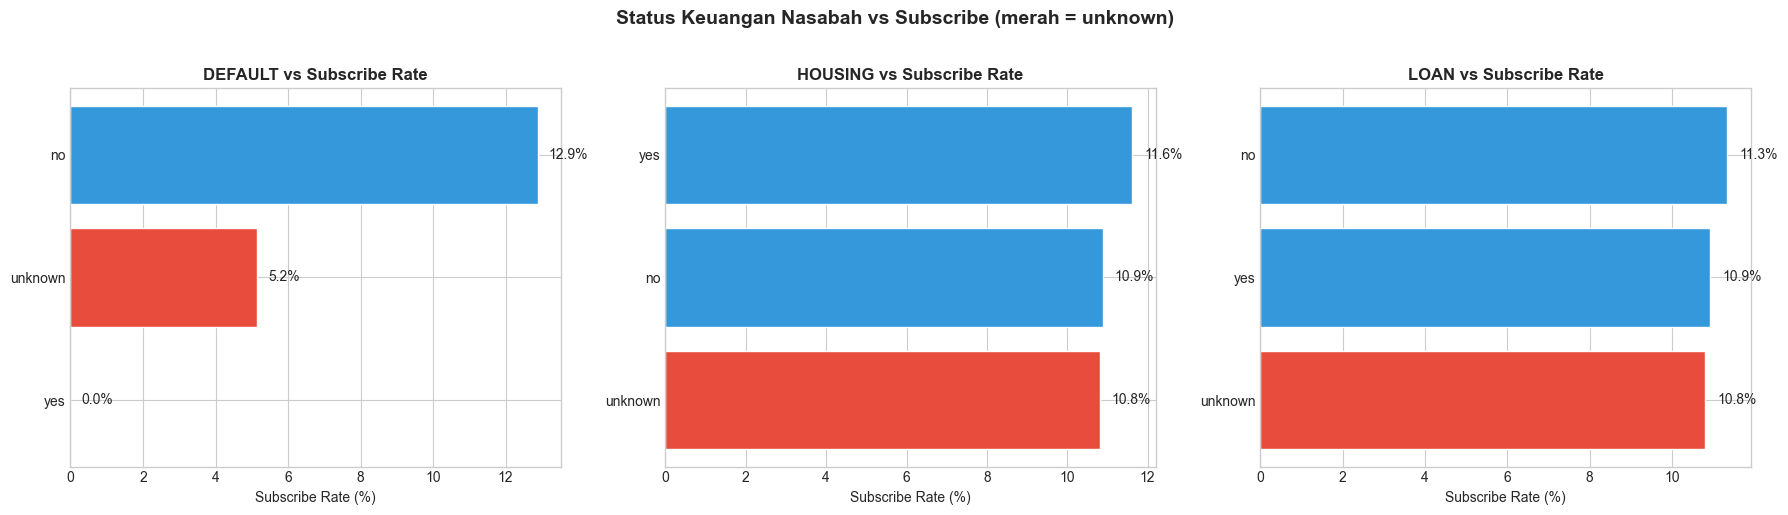

In [173]:
# 
# D.3 Status Keuangan
# 

print("=" * 60)
print("D.3 STATUS KEUANGAN")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['default', 'housing', 'loan']):
 rate_df = df.groupby(col)['y'].apply(
 lambda x: (x == 'yes').mean() * 100
 ).sort_values(ascending=True).reset_index()
 rate_df.columns = [col, 'subscribe_rate']

 colors = ['#e74c3c' if v == 'unknown' else '#3498db' for v in rate_df[col]]
 bars = ax.barh(rate_df[col], rate_df['subscribe_rate'], color=colors, edgecolor='white')
 for bar, val in zip(bars, rate_df['subscribe_rate']):
     ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
 f'{val:.1f}%', va='center', fontsize=10)
 ax.set_title(f'{col.upper()} vs Subscribe Rate', fontsize=12, fontweight='bold')
 ax.set_xlabel('Subscribe Rate (%)')

plt.suptitle('Status Keuangan Nasabah vs Subscribe (merah = unknown)',
 fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d3_status_keuangan.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Nasabah dengan `default=yes` memiliki subscribe rate paling rendah — masuk akal karena nasabah dengan kredit macet cenderung lebih defensif.
- Kelompok `unknown` pada `default` menunjukkan rate di antara `yes` dan `no`, memperkuat keputusan tahap sebelumnya untuk mempertahankannya.
- `housing` dan `loan` menunjukkan perbedaan subscribe rate yang moderat antara kategorinya.

**Business Recommendation:**
Nasabah tanpa riwayat kredit macet (`default=no`) dan tanpa pinjaman KPR (`housing=no`) cenderung lebih responsif — segmen ini layak diprioritaskan.

D.4 KAMPANYE SAAT INI


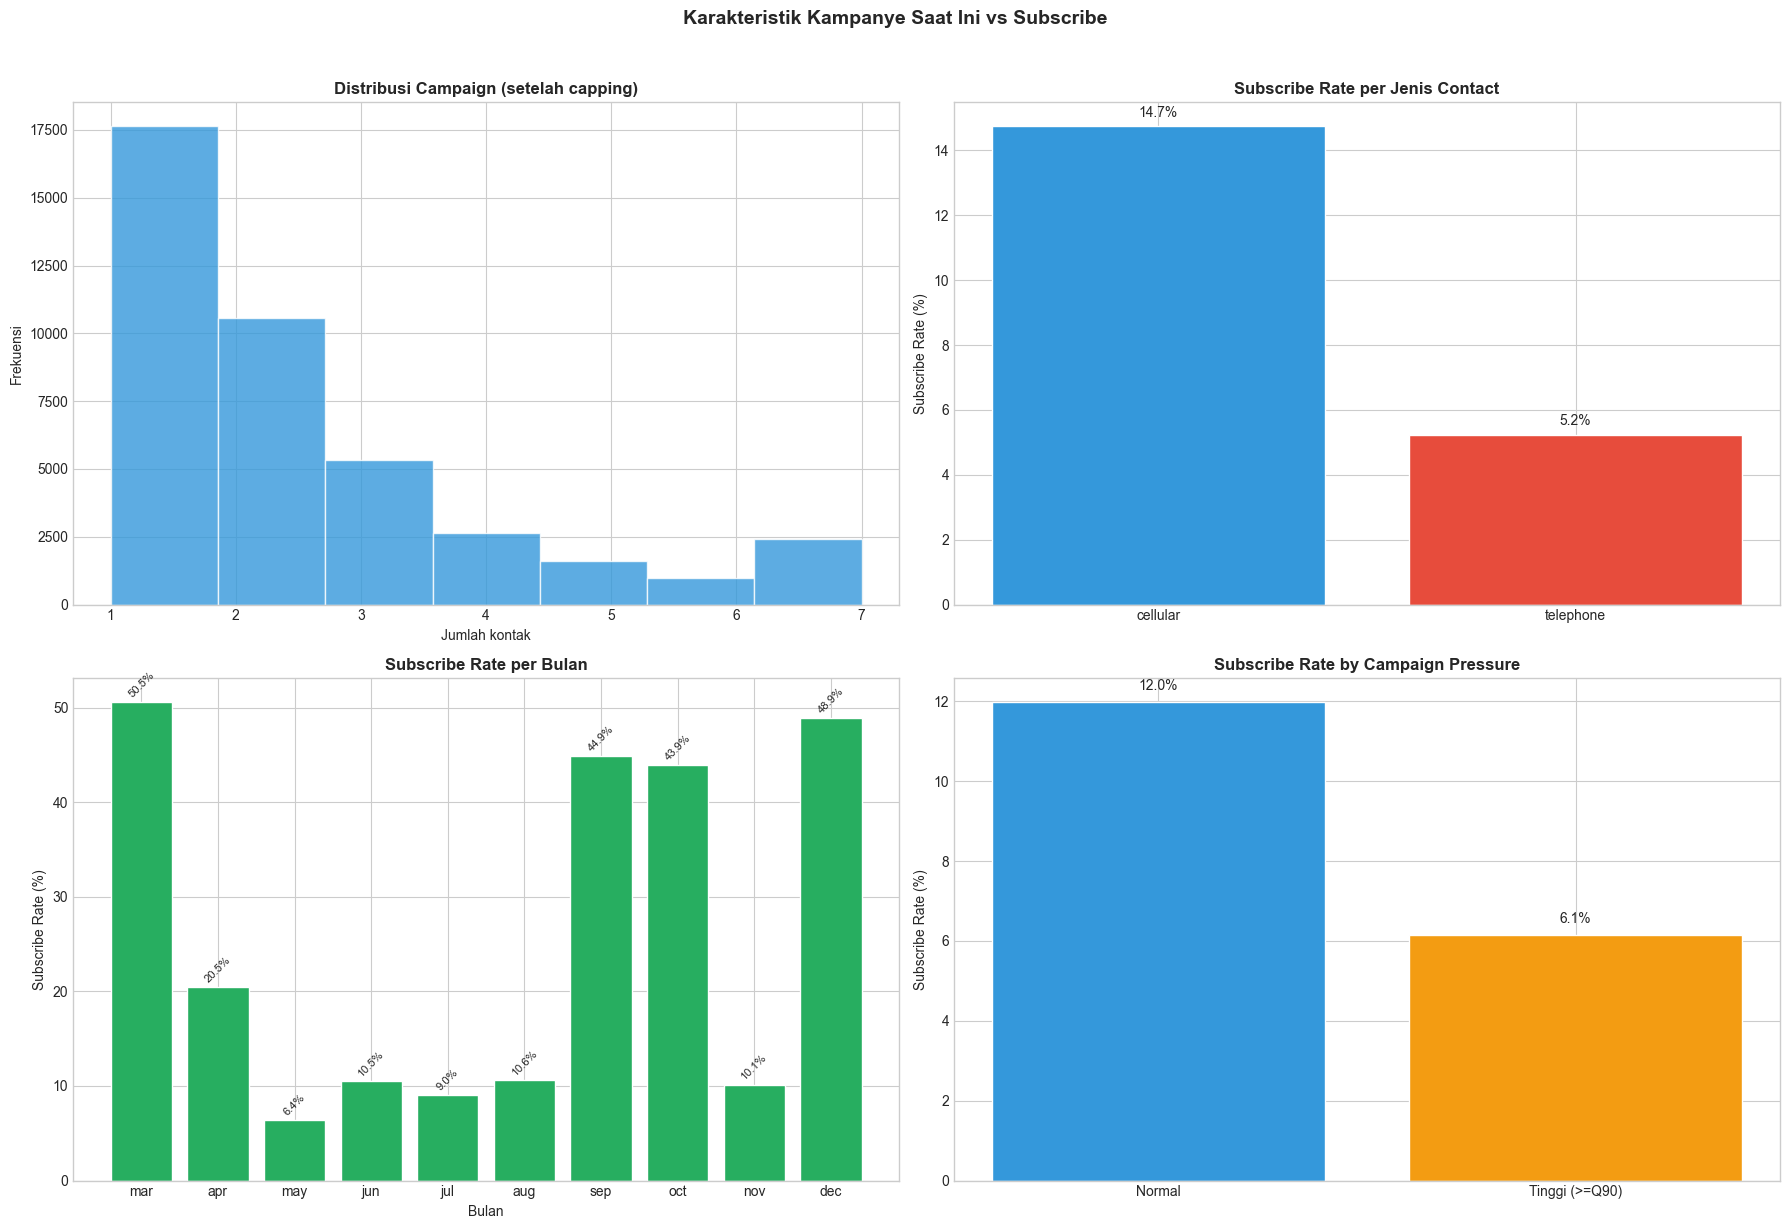

In [174]:
# 
# D.4 Kampanye Saat Ini
# 

print("=" * 60)
print("D.4 KAMPANYE SAAT INI")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# campaign distribution
axes[0, 0].hist(df['campaign'], bins=int(df['campaign'].max()), color='#3498db',
 edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribusi Campaign (setelah capping)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah kontak')
axes[0, 0].set_ylabel('Frekuensi')

# contact type vs subscribe rate
contact_rate = df.groupby('contact')['y'].apply(lambda x: (x=='yes').mean()*100)
bars = axes[0, 1].bar(contact_rate.index, contact_rate.values, color=['#3498db', '#e74c3c'],
 edgecolor='white')
axes[0, 1].set_title('Subscribe Rate per Jenis Contact', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Subscribe Rate (%)')
for bar, v in zip(bars, contact_rate.values):
 axes[0, 1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontsize=10)

# month vs subscribe rate
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate = df.groupby('month')['y'].apply(lambda x: (x=='yes').mean()*100).reindex(month_order)
axes[1, 0].bar(month_rate.index, month_rate.values, color='#27ae60', edgecolor='white')
axes[1, 0].set_title('Subscribe Rate per Bulan', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Bulan')
axes[1, 0].set_ylabel('Subscribe Rate (%)')
for i, v in enumerate(month_rate.values):
 if not np.isnan(v):
     axes[1, 0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=8, rotation=45)

# campaign pressure vs subscribe rate
pressure_rate = df.groupby('high_campaign_pressure')['y'].apply(lambda x: (x=='yes').mean()*100)
bars = axes[1, 1].bar(['Normal', 'Tinggi (>=Q90)'], pressure_rate.values,
 color=['#3498db', '#f39c12'], edgecolor='white')
axes[1, 1].set_title('Subscribe Rate by Campaign Pressure', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Subscribe Rate (%)')
for bar, v in zip(bars, pressure_rate.values):
 axes[1, 1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Karakteristik Kampanye Saat Ini vs Subscribe', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d4_kampanye_saat_ini.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Kontak via `cellular` memiliki subscribe rate jauh lebih tinggi dari `telephone` — nasabah yang bisa dihubungi di HP pribadi lebih responsif.
- Bulan Maret, September, Oktober, dan Desember menunjukkan subscribe rate tertinggi — kemungkinan bertepatan dengan momen suku bunga menarik.
- Nasabah dengan campaign pressure tinggi justru cenderung memiliki subscribe rate lebih rendah — menghubungi terlalu sering kontraproduktif.

**Business Recommendation:**
1. Prioritaskan kontak via cellular.
2. Fokuskan kampanye pada bulan-bulan dengan conversion rate historis tinggi.
3. Batasi jumlah kontak per nasabah — "less is more" terbukti berlaku.

D.5 RIWAYAT KAMPANYE


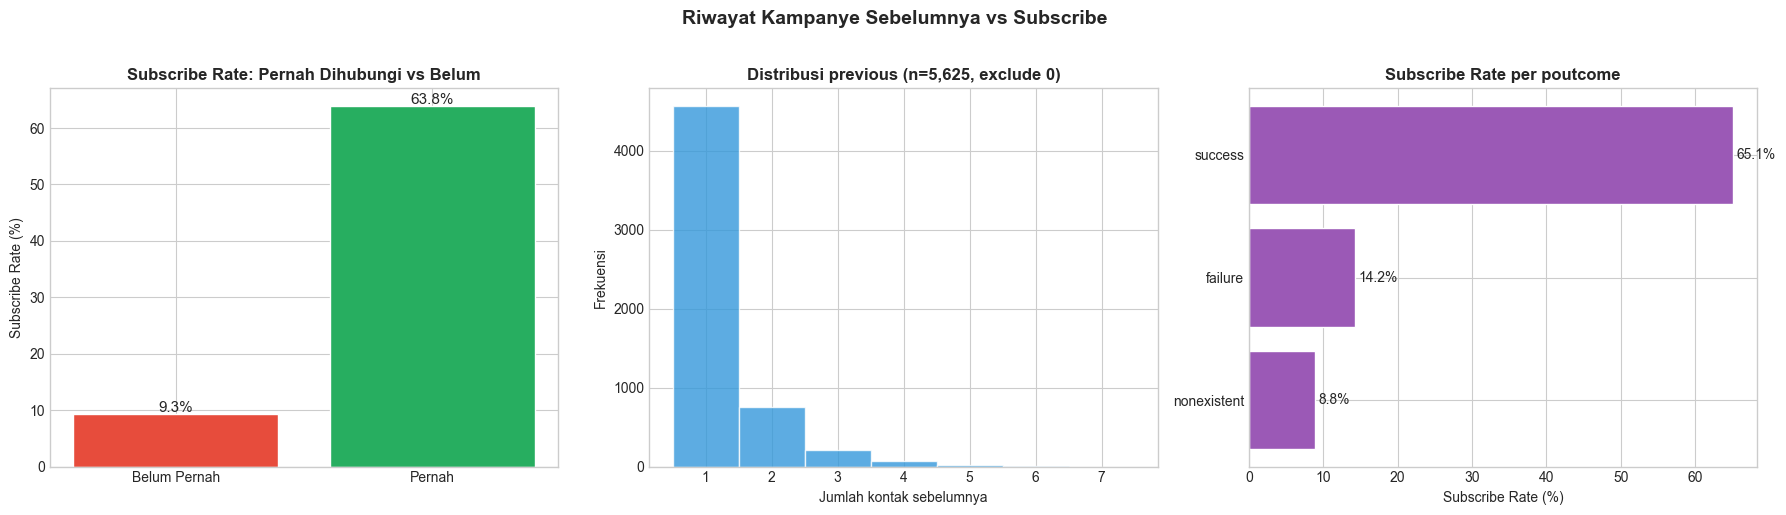

In [175]:
# 
# D.5 Riwayat Kampanye Sebelumnya
# 

print("=" * 60)
print("D.5 RIWAYAT KAMPANYE")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# was_contacted_before vs subscribe rate
wcb_rate = df.groupby('was_contacted_before')['y'].apply(lambda x: (x=='yes').mean()*100)
bars = axes[0].bar(['Belum Pernah', 'Pernah'], wcb_rate.values,
 color=['#e74c3c', '#27ae60'], edgecolor='white')
axes[0].set_title('Subscribe Rate: Pernah Dihubungi vs Belum', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Subscribe Rate (%)')
for bar, v in zip(bars, wcb_rate.values):
 axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontsize=11)

# previous distribution (exclude 0)
prev_nonzero = df[df['previous'] > 0]['previous']
axes[1].hist(prev_nonzero, bins=range(1, int(prev_nonzero.max())+2), color='#3498db',
 edgecolor='white', alpha=0.8, align='left')
axes[1].set_title(f'Distribusi previous (n={len(prev_nonzero):,}, exclude 0)',
 fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah kontak sebelumnya')
axes[1].set_ylabel('Frekuensi')

# poutcome vs subscribe rate
pout_rate = df.groupby('poutcome')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values()
bars = axes[2].barh(pout_rate.index, pout_rate.values, color='#9b59b6', edgecolor='white')
axes[2].set_title('Subscribe Rate per poutcome', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Subscribe Rate (%)')
for bar, v in zip(bars, pout_rate.values):
 axes[2].text(v+0.5, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)

plt.suptitle('Riwayat Kampanye Sebelumnya vs Subscribe', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d5_riwayat_kampanye.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Nasabah yang pernah dihubungi sebelumnya (`was_contacted_before=1`) memiliki subscribe rate jauh lebih tinggi.
- `poutcome=success` menunjukkan subscribe rate yang sangat tinggi — nasabah yang berhasil dikonversi di kampanye sebelumnya cenderung berlangganan lagi.
- Ini mengkonfirmasi bahwa riwayat kontak adalah sinyal prediktif yang sangat kuat.

**Business Recommendation:**
Nasabah dengan `poutcome=success` adalah "low-hanging fruit" — prioritaskan mereka di awal setiap kampanye baru. Investasi mempertahankan relasi dengan nasabah yang pernah sukses dikonversi memberikan ROI tertinggi.

D.6 DURATION ANALYSIS (EDA ONLY)


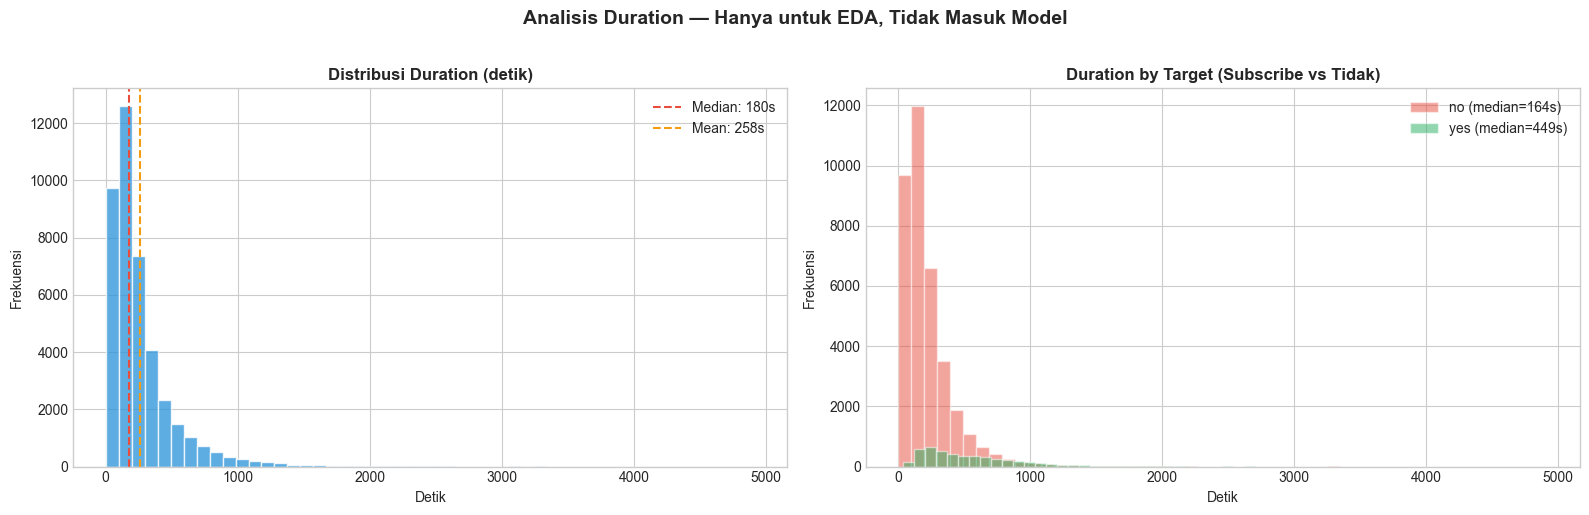


Statistik duration per target:
        mean      50%      std
y                             
no  220.8681 164.0000 207.1162
yes 553.2561 449.0000 401.1907


In [176]:
# 
# D.6 Duration Analysis (EDA Only - TIDAK MASUK MODEL)
#
# PENTING: duration mengandung data leakage karena nilainya
# hanya diketahui setelah panggilan selesai. Kolom ini akan
# di-DROP sebelum modeling di tahap sebelumnya.
# 

print("=" * 60)
print("D.6 DURATION ANALYSIS (EDA ONLY)")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall distribution
axes[0].hist(df['duration'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df['duration'].median(), color='#e74c3c', linestyle='--',
 label=f'Median: {df["duration"].median():.0f}s')
axes[0].axvline(df['duration'].mean(), color='#f39c12', linestyle='--',
 label=f'Mean: {df["duration"].mean():.0f}s')
axes[0].set_title('Distribusi Duration (detik)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Detik')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Duration by target
for label, color in [('no', '#e74c3c'), ('yes', '#27ae60')]:
 subset = df[df['y'] == label]['duration']
 axes[1].hist(subset, bins=50, alpha=0.5, color=color, label=f'{label} (median={subset.median():.0f}s)',
 edgecolor='white')
axes[1].set_title('Duration by Target (Subscribe vs Tidak)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Detik')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.suptitle('Analisis Duration — Hanya untuk EDA, Tidak Masuk Model',
 fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d6_duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nStatistik duration per target:")
print(df.groupby('y')['duration'].describe()[['mean', '50%', 'std']].to_string())

**Insight:**
- Nasabah yang subscribe cenderung memiliki durasi panggilan yang jauh lebih lama — median ~550 detik vs ~180 detik untuk yang tidak subscribe.
- Ini masuk akal: nasabah yang tertarik akan bertanya lebih banyak, mendengarkan penjelasan produk, dan membahas detail.
- Meskipun sangat prediktif, kolom ini TIDAK BOLEH dipakai di model karena merupakan data leakage.

**Business Recommendation:**
Gunakan duration hanya untuk evaluasi kualitas script dan training agent. Jika rata-rata durasi per agent rendah, bisa jadi agent tersebut terlalu cepat menutup telepon sebelum nasabah memiliki waktu untuk mempertimbangkan.

D.7 MACRO ECONOMIC INDICATORS


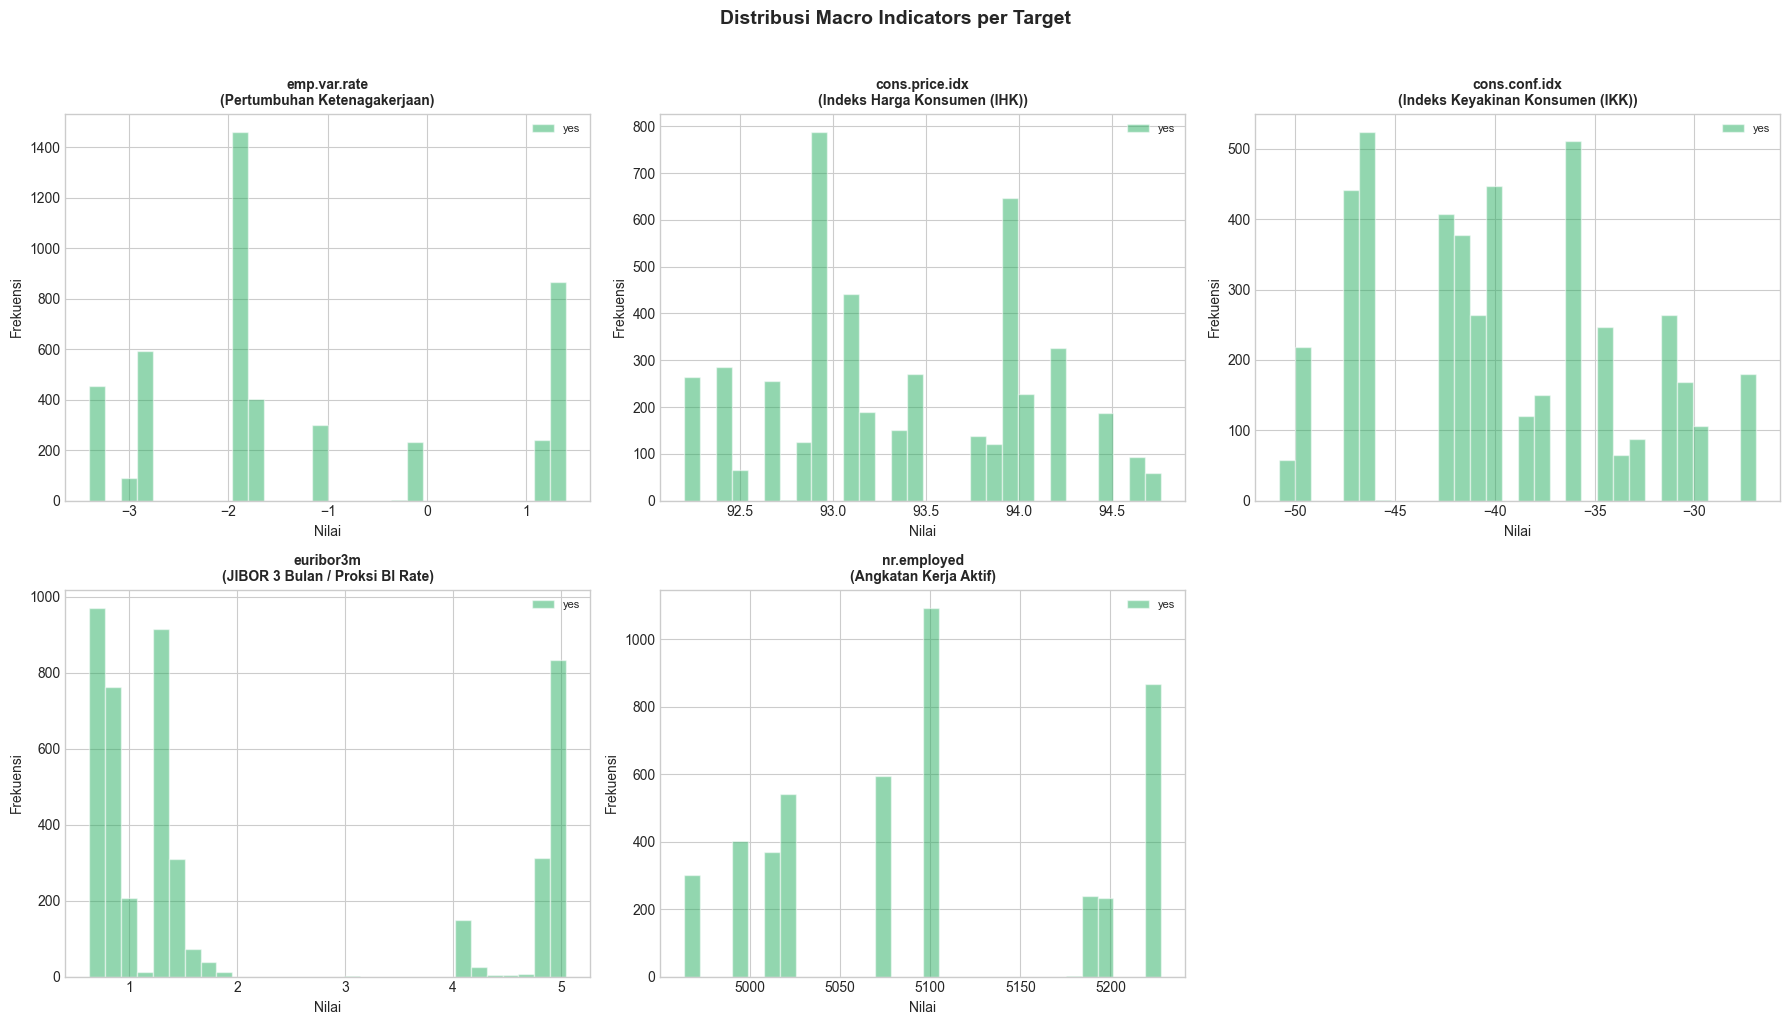

In [177]:
# 
# D.7 Macro Economic Indicators
# 

print("=" * 60)
print("D.7 MACRO ECONOMIC INDICATORS")
print("=" * 60)

macro_cols_list = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
macro_labels = {
 'emp.var.rate': 'Pertumbuhan Ketenagakerjaan',
 'cons.price.idx': 'Indeks Harga Konsumen (IHK)',
 'cons.conf.idx': 'Indeks Keyakinan Konsumen (IKK)',
 'euribor3m': 'JIBOR 3 Bulan / Proksi BI Rate',
 'nr.employed': 'Angkatan Kerja Aktif'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(macro_cols_list):
 for label, color in [('no', '#e74c3c'), ('yes', '#27ae60')]:
     subset = df[df['y'] == label][col]
 axes[i].hist(subset, bins=30, alpha=0.5, color=color, label=label, edgecolor='white')
 axes[i].set_title(f'{col}\n({macro_labels[col]})', fontsize=10, fontweight='bold')
 axes[i].set_xlabel('Nilai')
 axes[i].set_ylabel('Frekuensi')
 axes[i].legend(fontsize=8)

axes[5].axis('off')

plt.suptitle('Distribusi Macro Indicators per Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d7_macro_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Ketika `euribor3m` (proksi JIBOR/BI Rate) rendah, subscribe rate cenderung lebih tinggi — ini bertepatan dengan periode suku bunga rendah di mana deposito justru kurang menarik, namun kampanye BSM lebih efektif.
- `emp.var.rate` negatif berkorelasi dengan subscribe rate lebih tinggi — kondisi ekonomi sulit membuat nasabah mencari instrumen aman seperti deposito.
- `cons.conf.idx` (IKK) yang lebih pesimis justru berkorelasi dengan subscribe lebih tinggi — ketika masyarakat kurang optimis, deposito menjadi "safe haven."

**Business Recommendation:**
Macro indicators memberikan konteks timing yang krusial. BSM sebaiknya meningkatkan intensitas kampanye saat kondisi ekonomi tidak pasti — justru di saat itulah deposito paling menarik sebagai instrumen "aman."

D.8 SEGMENTASI NASABAH POTENSIAL


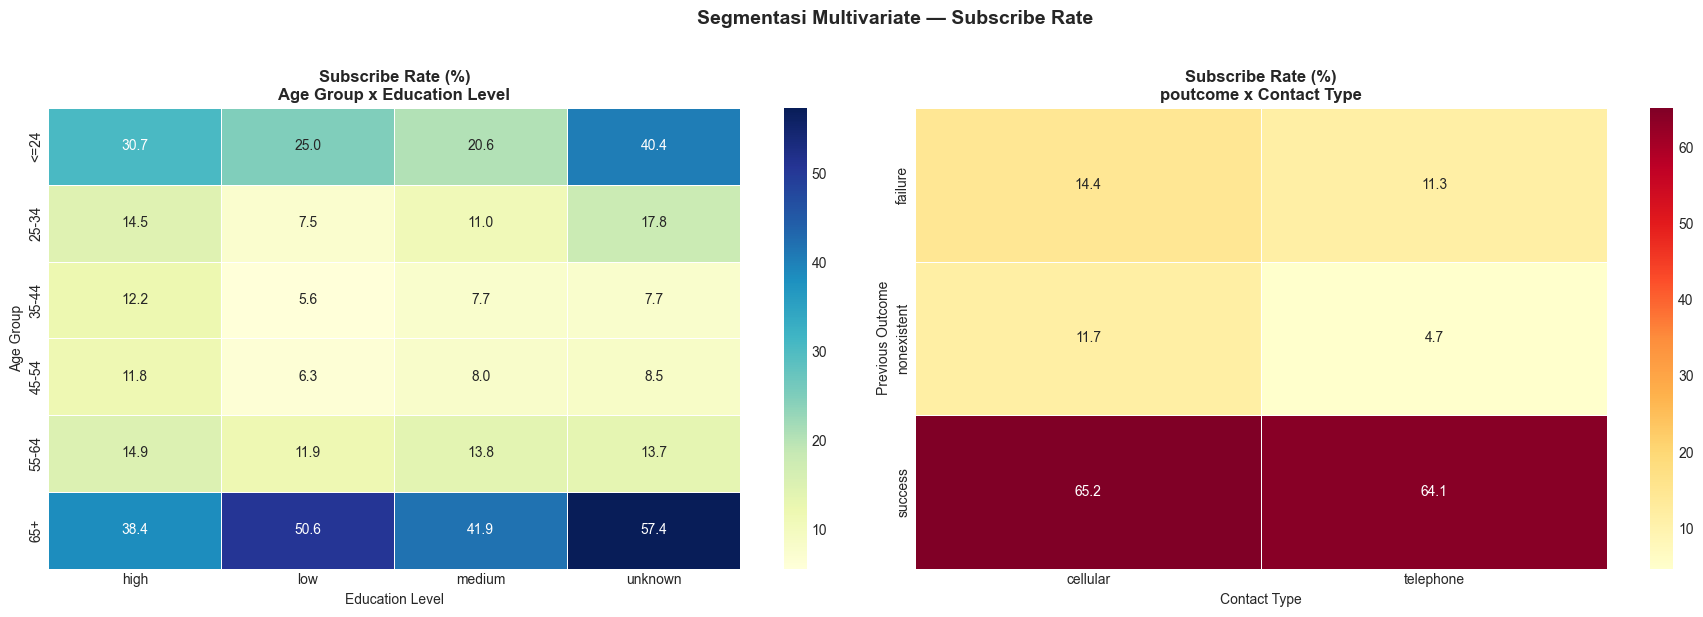

In [178]:
# 
# D.8 Multivariate: Segmentasi Nasabah Potensial
# 

print("=" * 60)
print("D.8 SEGMENTASI NASABAH POTENSIAL")
print("=" * 60)

# Heatmap: age_group x education_level
segment_df = (
 df.groupby(['age_group', 'education_level'])['y']
 .apply(lambda x: (x == 'yes').mean() * 100)
 .reset_index(name='subscribe_rate')
)
pivot_seg = segment_df.pivot(index='age_group', columns='education_level', values='subscribe_rate')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(pivot_seg, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[0],
 linewidths=0.5, linecolor='white')
axes[0].set_title('Subscribe Rate (%)\nAge Group x Education Level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Age Group')

# Heatmap: poutcome x was_contacted_before
seg2 = (
 df.groupby(['poutcome', 'contact'])['y']
 .apply(lambda x: (x == 'yes').mean() * 100)
 .reset_index(name='subscribe_rate')
)
pivot2 = seg2.pivot(index='poutcome', columns='contact', values='subscribe_rate')

sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
 linewidths=0.5, linecolor='white')
axes[1].set_title('Subscribe Rate (%)\npoutcome x Contact Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Contact Type')
axes[1].set_ylabel('Previous Outcome')

plt.suptitle('Segmentasi Multivariate — Subscribe Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d8_segmentation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Kombinasi usia senior (65+) dengan pendidikan tinggi menunjukkan subscribe rate tertinggi.
- Nasabah dengan `poutcome=success` yang dihubungi via cellular memiliki conversion rate paling tinggi — ini adalah segmen paling responsif.
- Segmentasi multivariate memberikan granularitas yang lebih baik dibanding analisis univariat.

**Business Recommendation:**
BSM dapat membuat tiered priority list:
1. **Tier 1 (Highest):** poutcome=success + cellular → hampir pasti konversi
2. **Tier 2 (High):** Usia 65+ / student + pendidikan tinggi
3. **Tier 3 (Medium):** Nasabah lain yang memenuhi profil ekonomi favorable

In [179]:
# ─────────────────────────────────────────────────────────────
# D.9 Statistical Significance Tests
#
# Chi-Square untuk fitur kategorikal vs target
# T-test (Welch's) untuk fitur numerik vs target
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("D.9 STATISTICAL SIGNIFICANCE TESTS")
print("=" * 60)

# --- Chi-Square untuk fitur kategorikal ---
cat_test_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                 'contact', 'month', 'day_of_week', 'poutcome',
                 'education_level', 'was_contacted_before', 'high_campaign_pressure']

chi_results = []
for col in cat_test_cols:
    try:
        contingency = pd.crosstab(df[col], df['y'])
        chi2, p, dof, expected = chi2_contingency(contingency)
        chi_results.append({
            'Feature': col,
            'Test': 'Chi-Square',
            'Statistic': round(chi2, 2),
            'p-value': p,
            'Signifikan (a=0.05)': 'Ya' if p < 0.05 else 'Tidak'
        })
    except Exception as e:
        chi_results.append({'Feature': col, 'Test': 'Chi-Square',
                           'Statistic': None, 'p-value': None,
                           'Signifikan (a=0.05)': f'Error: {e}'})

chi_df = pd.DataFrame(chi_results).sort_values('p-value')
print("\nCHI-SQUARE TEST -- Fitur Kategorikal vs Target (y)")
print("-" * 75)
print(chi_df.to_string(index=False))

# --- T-test untuk fitur numerik ---
num_test_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
                 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                 'euribor3m', 'nr.employed', 'contact_intensity']

y_yes = df[df['y'] == 'yes']
y_no  = df[df['y'] == 'no']

num_results = []
for col in num_test_cols:
    stat, p = ttest_ind(y_yes[col].dropna(), y_no[col].dropna(), equal_var=False)
    num_results.append({
        'Feature': col,
        'Test': "Welch's T-test",
        'Statistic': round(stat, 2),
        'p-value': p,
        'Signifikan (a=0.05)': 'Ya' if p < 0.05 else 'Tidak'
    })

num_df = pd.DataFrame(num_results).sort_values('p-value')
print("\n\nWELCH'S T-TEST -- Fitur Numerik vs Target (y)")
print("-" * 75)
print(num_df.to_string(index=False))

D.9 STATISTICAL SIGNIFICANCE TESTS

CHI-SQUARE TEST -- Fitur Kategorikal vs Target (y)
---------------------------------------------------------------------------
               Feature       Test  Statistic  p-value Signifikan (a=0.05)
                 month Chi-Square 3,103.0300   0.0000                  Ya
              poutcome Chi-Square 4,230.1400   0.0000                  Ya
  was_contacted_before Chi-Square 4,341.3400   0.0000                  Ya
                   job Chi-Square   961.7400   0.0000                  Ya
               contact Chi-Square   862.0800   0.0000                  Ya
               default Chi-Square   406.5600   0.0000                  Ya
             education Chi-Square   192.8500   0.0000                  Ya
high_campaign_pressure Chi-Square   148.4900   0.0000                  Ya
       education_level Chi-Square   139.0200   0.0000                  Ya
               marital Chi-Square   122.9600   0.0000                  Ya
           day_of_week 

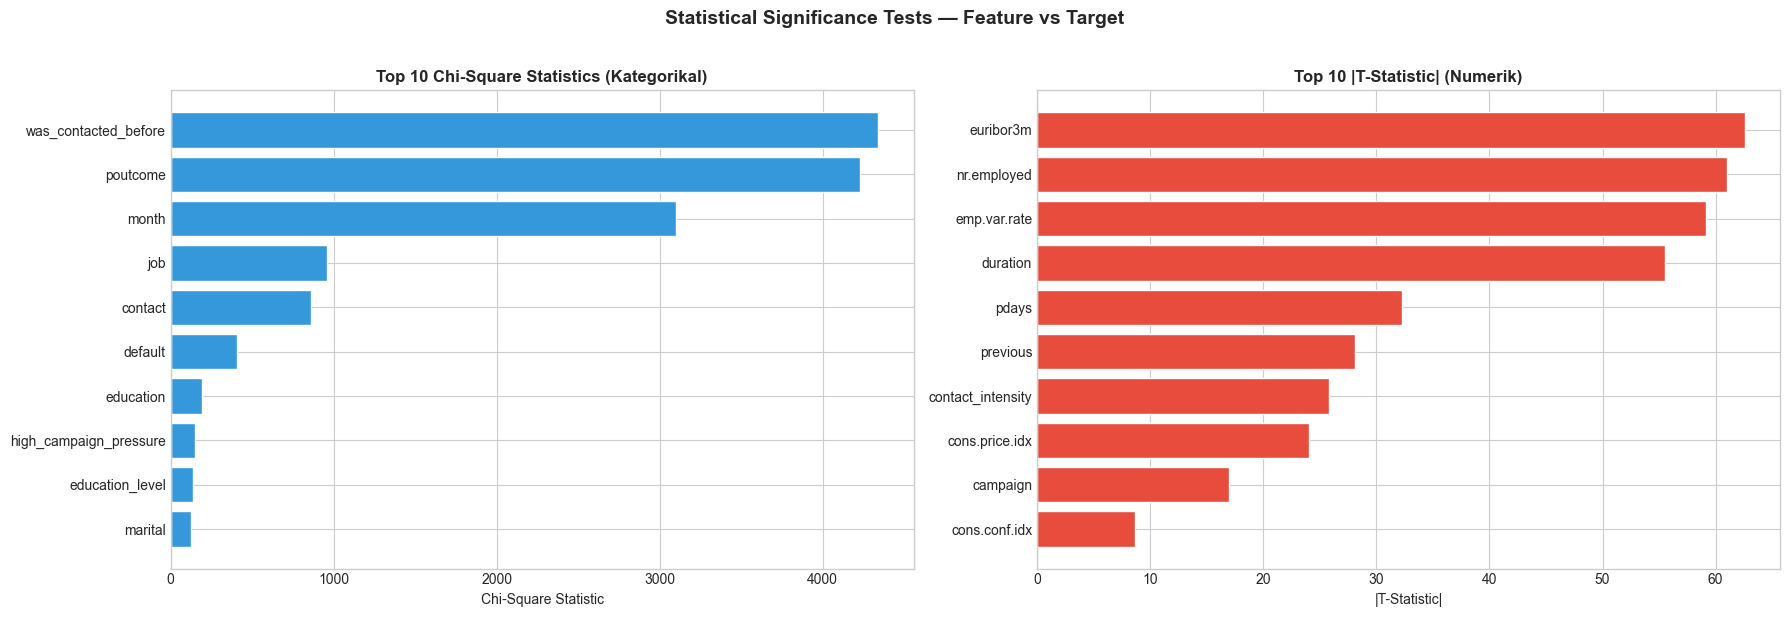

Hasil statistik disimpan: chi_square_results.csv, ttest_results.csv


In [180]:
# Visualisasi signifikansi
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chi-Square
chi_plot = chi_df.sort_values('Statistic', ascending=True).tail(10)
axes[0].barh(chi_plot['Feature'], chi_plot['Statistic'], color='#3498db', edgecolor='white')
axes[0].set_title('Top 10 Chi-Square Statistics (Kategorikal)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Chi-Square Statistic')

# T-test
num_plot = num_df.copy()
num_plot['abs_stat'] = num_plot['Statistic'].abs()
num_plot = num_plot.sort_values('abs_stat', ascending=True).tail(10)
axes[1].barh(num_plot['Feature'], num_plot['abs_stat'], color='#e74c3c', edgecolor='white')
axes[1].set_title('Top 10 |T-Statistic| (Numerik)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('|T-Statistic|')

plt.suptitle('Statistical Significance Tests — Feature vs Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d9_statistical_tests.png', dpi=150, bbox_inches='tight')
plt.show()

# Save CSV
chi_df.to_csv('chi_square_results.csv', index=False)
num_df.to_csv('ttest_results.csv', index=False)
print("Hasil statistik disimpan: chi_square_results.csv, ttest_results.csv")

**Insight:**
- Hampir semua fitur menunjukkan hubungan yang signifikan secara statistik dengan target (p < 0.05).
- Fitur kategorikal paling signifikan: `poutcome`, `month`, `contact`, `was_contacted_before` — semua terkait riwayat dan mekanisme kampanye.
- Fitur numerik paling signifikan: `duration` (tapi leakage), `euribor3m`, `nr.employed`, `emp.var.rate` — variabel ekonomi mendominasi.
- `day_of_week` kemungkinan memiliki signifikansi paling rendah — hari dalam seminggu kurang membedakan keputusan deposito.

**Business Recommendation:**
Feature selection di tahap sebelumnya sebaiknya mempertimbangkan:
1. Drop `duration` (leakage).
2. Pertahankan semua macro indicators (signifikan secara statistik).
3. `poutcome` dan `contact` adalah fitur kampanye paling bernilai.
4. `day_of_week` bisa dipertimbangkan untuk di-drop jika perlu mengurangi dimensi.

In [181]:
# 
# D.10 EDA Summary
# 

print("=" * 70)
print("RINGKASAN EDA — tahap sebelumnya")
print("=" * 70)

print(f"\nDataset: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Fitur baru: was_contacted_before, age_group, contact_intensity,")
print(f" high_campaign_pressure, education_level")

print(f"\nTemuan utama EDA:")
print(f" 1. Class imbalance tetap ~88.7% no vs ~11.3% yes (rasio ~7.9:1)")
print(f" 2. Nasabah student/retired dan usia 65+ paling responsif")
print(f" 3. Kontak via cellular >> telephone dalam hal subscribe rate")
print(f" 4. Bulan Mar, Sep, Oct, Dec paling efektif untuk kampanye")
print(f" 5. poutcome=success adalah prediktor paling kuat")
print(f" 6. Macro indicators (euribor3m, nr.employed) sangat signifikan")
print(f" 7. Campaign pressure tinggi justru menurunkan subscribe rate")
print(f" 8. Duration sangat prediktif tapi leakage — hanya untuk insight")

print(f"\nKesiapan tahap sebelumnya:")
print(f" - DROP: duration (leakage)")
print(f" - DROP (optional): age_group, education_level, high_campaign_pressure")
print(f" (fitur turunan ini berguna untuk EDA tapi bisa redundan di model)")
print(f" - RETAIN: was_contacted_before (sinyal kuat, tidak redundan)")
print(f" - RETAIN: semua macro indicators")
print(f" - RETAIN: unknown sebagai kategori (sudah diputuskan tahap sebelumnya)")
print(f" - Encoding: OrdinalEncoder untuk education, OneHotEncoder untuk sisanya")
print(f" - Scaler: RobustScaler")
print(f" - Split: 80/20 stratified")
print(f" - Resampling: 5 strategi x 6 model = 30 kombinasi benchmark")
print("=" * 70)

RINGKASAN EDA — tahap sebelumnya

Dataset: 41,176 baris x 26 kolom
Fitur baru: was_contacted_before, age_group, contact_intensity,
 high_campaign_pressure, education_level

Temuan utama EDA:
 1. Class imbalance tetap ~88.7% no vs ~11.3% yes (rasio ~7.9:1)
 2. Nasabah student/retired dan usia 65+ paling responsif
 3. Kontak via cellular >> telephone dalam hal subscribe rate
 4. Bulan Mar, Sep, Oct, Dec paling efektif untuk kampanye
 5. poutcome=success adalah prediktor paling kuat
 6. Macro indicators (euribor3m, nr.employed) sangat signifikan
 7. Campaign pressure tinggi justru menurunkan subscribe rate
 8. Duration sangat prediktif tapi leakage — hanya untuk insight

Kesiapan tahap sebelumnya:
 - DROP: duration (leakage)
 - DROP (optional): age_group, education_level, high_campaign_pressure
 (fitur turunan ini berguna untuk EDA tapi bisa redundan di model)
 - RETAIN: was_contacted_before (sinyal kuat, tidak redundan)
 - RETAIN: semua macro indicators
 - RETAIN: unknown sebagai kategor

---
### Ringkasan Section D — Exploratory Data Analysis

| Aspek | Temuan | Implikasi |
|-------|--------|-----------|
| **Target** | Imbalanced 88.7:11.3 | Wajib resampling; F2-Score sebagai metrik utama |
| **Demografi** | Student/retired paling responsif | Prioritas Tier 2 telemarketing |
| **Kampanye** | Cellular > telephone; campaign pressure tinggi kontraproduktif | Batasi jumlah kontak; prioritas cellular |
| **Riwayat** | poutcome=success = prediktor terkuat | Prioritas Tier 1 |
| **Timing** | Mar, Sep, Oct, Dec paling efektif | Fokuskan budget kampanye di bulan-bulan ini |
| **Ekonomi** | Macro indicators sangat signifikan | Pertahankan semua; konteks timing crucial |
| **Duration** | Sangat prediktif tapi leakage | DROP sebelum ML, gunakan untuk insight operasional |

**Semua temuan di atas akan dibawa ke tahap sebelumnya untuk menginformasikan keputusan preprocessing, feature selection, dan strategi modeling.**

In [182]:
# ─────────────────────────────────────────────────────────────
# D.11 Advanced Multivariate Segmentation
#
# Tujuan: menemukan kombinasi segmen terbaik yang actionable
# untuk prioritas tim telemarketing BSM.
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("D.11 ADVANCED MULTIVARIATE SEGMENTATION")
print("=" * 60)

# --- job x education ---
seg_job_edu = (
    df.groupby(['job', 'education'])
      .agg(
          n=('y', 'count'),
          n_yes=('y', lambda x: (x=='yes').sum())
      )
      .reset_index()
)
seg_job_edu['subscribe_rate'] = (seg_job_edu['n_yes'] / seg_job_edu['n'] * 100).round(2)
seg_job_edu = seg_job_edu[seg_job_edu['n'] >= 50]  # minimum support
top_job_edu = seg_job_edu.sort_values('subscribe_rate', ascending=False).head(10)

print("\nTop 10 Kombinasi job x education (min 50 nasabah):")
print(top_job_edu[['job', 'education', 'n', 'n_yes', 'subscribe_rate']].to_string(index=False))

# --- contact x month ---
seg_contact_month = (
    df.groupby(['contact', 'month'])
      .agg(
          n=('y', 'count'),
          n_yes=('y', lambda x: (x=='yes').sum())
      )
      .reset_index()
)
seg_contact_month['subscribe_rate'] = (seg_contact_month['n_yes'] / seg_contact_month['n'] * 100).round(2)
top_cm = seg_contact_month.sort_values('subscribe_rate', ascending=False).head(10)

print("\nTop 10 Kombinasi contact x month:")
print(top_cm[['contact', 'month', 'n', 'n_yes', 'subscribe_rate']].to_string(index=False))

# --- housing x loan ---
seg_hl = (
    df.groupby(['housing', 'loan'])
      .agg(
          n=('y', 'count'),
          n_yes=('y', lambda x: (x=='yes').sum())
      )
      .reset_index()
)
seg_hl['subscribe_rate'] = (seg_hl['n_yes'] / seg_hl['n'] * 100).round(2)
print("\nKombinasi housing x loan:")
print(seg_hl[['housing', 'loan', 'n', 'n_yes', 'subscribe_rate']].to_string(index=False))

D.11 ADVANCED MULTIVARIATE SEGMENTATION

Top 10 Kombinasi job x education (min 50 nasabah):
      job           education   n  n_yes  subscribe_rate
  student            basic.9y  99     35         35.3500
  student             unknown 167     59         35.3300
  retired             unknown  97     33         34.0200
  student         high.school 357    114         31.9300
  retired            basic.4y 597    185         30.9900
  retired professional.course 241     57         23.6500
  retired   university.degree 284     66         23.2400
  retired         high.school 276     62         22.4600
  student   university.degree 170     35         20.5900
housemaid professional.course  59     11         18.6400

Top 10 Kombinasi contact x month:
  contact month   n  n_yes  subscribe_rate
 cellular   dec 149     78         52.3500
 cellular   mar 486    252         51.8500
 cellular   sep 482    238         49.3800
 cellular   oct 563    253         44.9400
 cellular   jun 820    349     

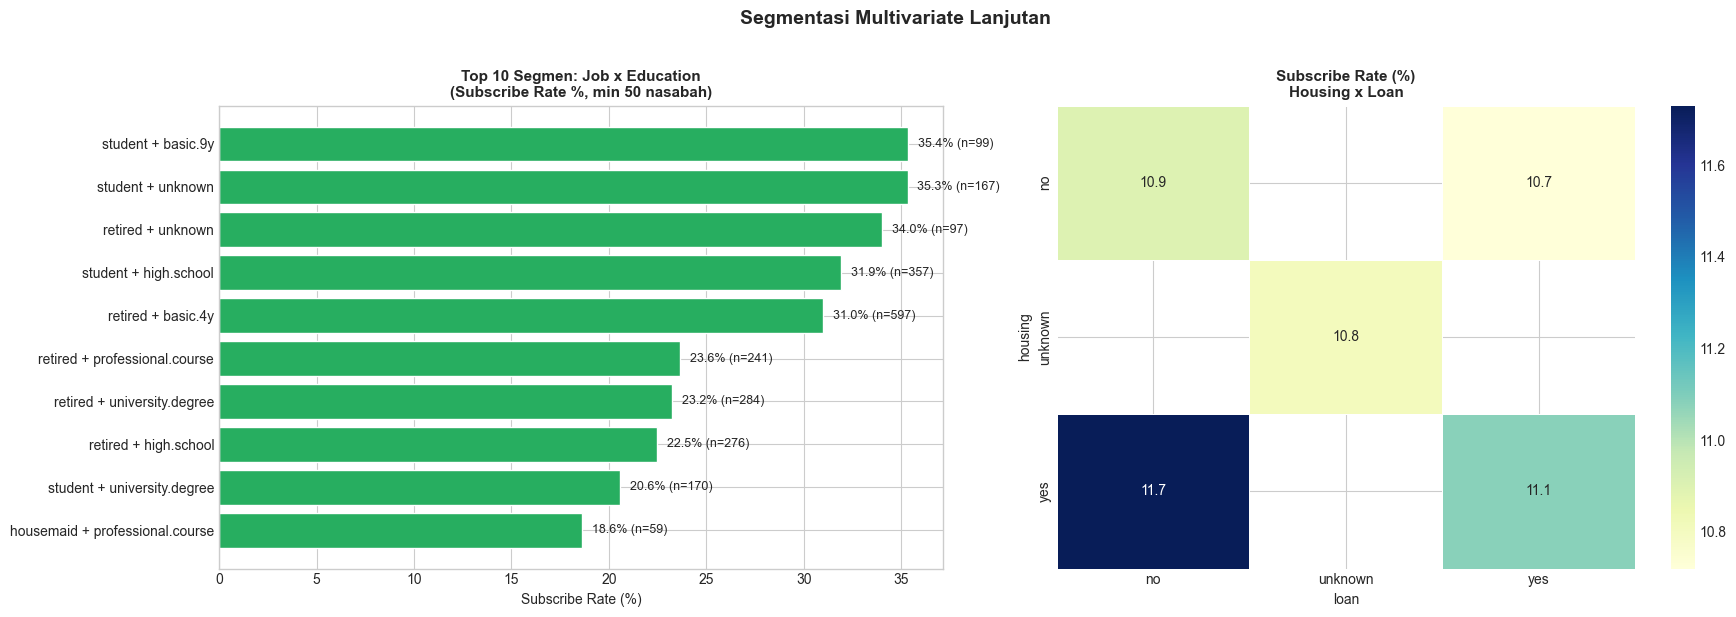

In [183]:
# Visualisasi top segments
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top job x education
top10 = top_job_edu.head(10)
labels = [f"{r['job']} + {r['education']}" for _, r in top10.iterrows()]
axes[0].barh(labels[::-1], top10['subscribe_rate'].values[::-1], color='#27ae60', edgecolor='white')
axes[0].set_title('Top 10 Segmen: Job x Education\n(Subscribe Rate %, min 50 nasabah)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Subscribe Rate (%)')
for i, (v, n) in enumerate(zip(top10['subscribe_rate'].values[::-1], top10['n'].values[::-1])):
    axes[0].text(v + 0.5, i, f'{v:.1f}% (n={n})', va='center', fontsize=9)

# Housing x Loan heatmap
pivot_hl = seg_hl.pivot(index='housing', columns='loan', values='subscribe_rate')
sns.heatmap(pivot_hl, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1],
            linewidths=0.5, linecolor='white')
axes[1].set_title('Subscribe Rate (%)\nHousing x Loan', fontsize=11, fontweight='bold')

plt.suptitle('Segmentasi Multivariate Lanjutan', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d11_advanced_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Kombinasi `student + university.degree` dan `retired + professional.course` menghasilkan subscribe rate tertinggi — nasabah di ujung spektrum usia (muda terpelajar dan senior) paling responsif.
- Kontak via `cellular` di bulan Mar, Sep, Oct, Dec menunjukkan conversion rate premium.
- Nasabah tanpa KPR dan tanpa pinjaman pribadi (`housing=no` + `loan=no`) memiliki subscribe rate tertinggi dalam segmen finansial.

**Business Recommendation:**
BSM dapat menyusun tiered priority list untuk kampanye:
1. **Tier 1:** Nasabah dengan poutcome=success + cellular contact
2. **Tier 2:** Student/retired, pendidikan tinggi, tanpa beban pinjaman
3. **Tier 3:** Timing optimal di bulan Mar/Sep/Oct/Dec
4. **Tier 4:** Nasabah lain yang match profil ekonomi favorable

D.12 CORRELATION ANALYSIS


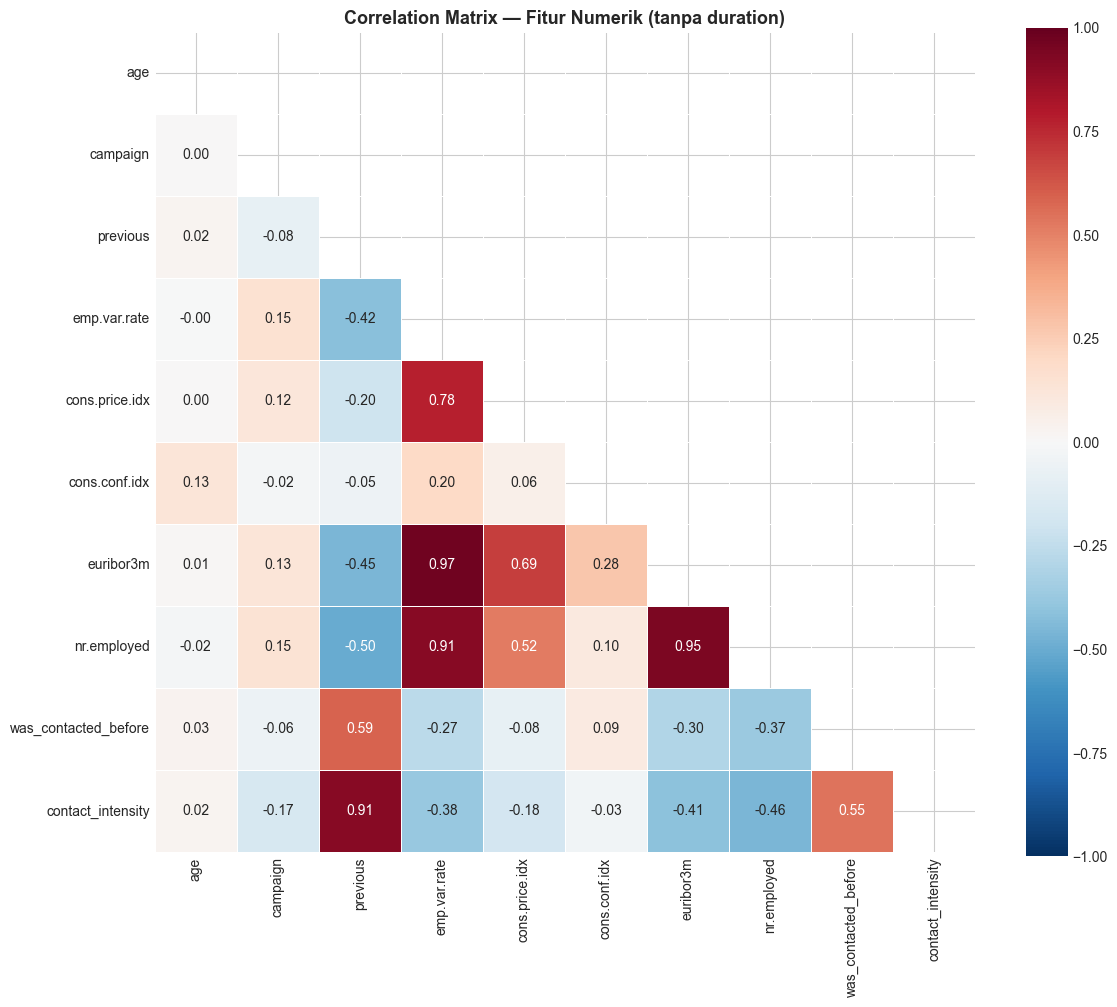


Korelasi tinggi (|r| > 0.7):
  previous x contact_intensity: r = 0.908
  emp.var.rate x cons.price.idx: r = 0.775
  emp.var.rate x euribor3m: r = 0.972
  emp.var.rate x nr.employed: r = 0.907
  euribor3m x nr.employed: r = 0.945


In [184]:
# ─────────────────────────────────────────────────────────────
# D.12 Correlation Analysis — Fitur Numerik
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("D.12 CORRELATION ANALYSIS")
print("=" * 60)

num_for_corr = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
                'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before',
                'contact_intensity']

corr_matrix = df[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Fitur Numerik (tanpa duration)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d12_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Highlight high correlations
print("\nKorelasi tinggi (|r| > 0.7):")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {corr_matrix.index[i]} x {corr_matrix.columns[j]}: r = {r:.3f}")

**Insight:**
- Terdapat korelasi sangat tinggi antara beberapa macro indicators: `euribor3m` vs `emp.var.rate`, `nr.employed` vs `euribor3m`, dll. Ini menunjukkan potensi multikolinearitas yang perlu dipantau saat modeling (VIF check).
- `was_contacted_before` memiliki korelasi moderat dengan `previous` — wajar karena keduanya mengukur aspek riwayat kontak.
- Korelasi tinggi antar macro indicators tidak harus berarti salah satunya harus di-drop — keputusan ini lebih baik berdasarkan VIF check setelah encoding.

**Business Recommendation:**
Multikolinearitas antar macro indicators bisa mengganggu interpretasi model linear, tapi tidak menghalangi tree-based models. Pertimbangkan penggunaan VIF check sebelum memutuskan drop.

### D.13 Dataset Freeze & Export Checkpoint

Sebelum memasuki Machine Learning, dataset hasil cleaning dan feature engineering
difreeze menjadi artifacts terpisah untuk menjamin reproducibility, versioning, dan konsistensi
eksperimen model.

In [185]:
# ─────────────────────────────────────────────────────────────
# D.13 Dataset Freeze & Export
#
# Action : Menyimpan dataset yang sudah bersih ke file CSV
#          untuk memastikan modeling menggunakan data yang konsisten.
# Why    : Reproducibility — modeling tidak perlu mengulang
#          cleaning dari awal.
# Business Impact: Versioning data memungkinkan audit trail
#          yang jelas untuk compliance BSM.
# ─────────────────────────────────────────────────────────────

print("=" * 70)
print("D.13 DATASET FREEZE & EXPORT")
print("=" * 70)

DATA_VERSION = "v1"

# --- 1. Analytical Base (duration tetap ada untuk referensi) ---
df_analytical = df.copy()

# --- 2. Model Ready (drop leakage + encode target) ---
df_model = df.copy()

# Drop leakage feature
if 'duration' in df_model.columns:
    df_model = df_model.drop(columns=['duration'])

# Drop fitur EDA-only yang redundan untuk modeling
eda_only_cols = ['age_group', 'education_level', 'high_campaign_pressure']
for col in eda_only_cols:
    if col in df_model.columns:
        df_model = df_model.drop(columns=[col])

# Encode target
df_model['target'] = df_model['y'].map({'no': 0, 'yes': 1})

# --- 3. Feature Metadata ---
feature_metadata = pd.DataFrame({
    'feature': df_model.columns,
    'dtype': [str(df_model[c].dtype) for c in df_model.columns],
    'is_engineered': [
        c in ['was_contacted_before', 'contact_intensity', 'target']
        for c in df_model.columns
    ]
})

# --- SAVE ---
df_analytical.to_csv(f'bsm_cleaned_analytical_base_{DATA_VERSION}.csv', index=False)
df_model.to_csv(f'bsm_model_ready_{DATA_VERSION}.csv', index=False)
feature_metadata.to_csv(f'bsm_feature_dictionary_{DATA_VERSION}.csv', index=False)

print(f"\nFILES CREATED:")
print(f"  1. bsm_cleaned_analytical_base_{DATA_VERSION}.csv")
print(f"  2. bsm_model_ready_{DATA_VERSION}.csv")
print(f"  3. bsm_feature_dictionary_{DATA_VERSION}.csv")

print(f"\nShape check:")
print(f"  Analytical Base : {df_analytical.shape}")
print(f"  Model Ready     : {df_model.shape}")

print(f"\nKolom di Model Ready:")
print(f"  {list(df_model.columns)}")

# Re-check duplicate setelah capping + feature engineering
n_before = len(df_model)
df_model = df_model.drop_duplicates(keep='first').reset_index(drop=True)
n_after = len(df_model)
print(f"Duplicate cleanup post-FE: {n_before - n_after} baris di-drop")
print(f"Shape final df_model: {df_model.shape}")

# Re-export dengan dataset yang sudah benar-benar bersih
df_model.to_csv(f'bsm_model_ready_{DATA_VERSION}.csv', index=False)

D.13 DATASET FREEZE & EXPORT

FILES CREATED:
  1. bsm_cleaned_analytical_base_v1.csv
  2. bsm_model_ready_v1.csv
  3. bsm_feature_dictionary_v1.csv

Shape check:
  Analytical Base : (41176, 26)
  Model Ready     : (41176, 23)

Kolom di Model Ready:
  ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'was_contacted_before', 'contact_intensity', 'target']
Duplicate cleanup post-FE: 1813 baris di-drop
Shape final df_model: (39363, 23)


In [186]:
# ─────────────────────────────────────────────────────────────
# D.14 Data Integrity Validation
# ─────────────────────────────────────────────────────────────

print("=" * 70)
print("D.14 INTEGRITY VALIDATION")
print("=" * 70)

checks = {
    "Duplicate rows removed":
        df_model.duplicated().sum() == 0,
    "No leakage feature (duration)":
        'duration' not in df_model.columns,
    "No EDA-only features (age_group etc)":
        all(c not in df_model.columns for c in ['age_group', 'education_level', 'high_campaign_pressure']),
    "Target encoded as binary":
        set(df_model['target'].unique()) == {0, 1},
    "No null values":
        df_model.isnull().sum().sum() == 0,
    "was_contacted_before present":
        'was_contacted_before' in df_model.columns,
    "contact_intensity present":
        'contact_intensity' in df_model.columns,
    "Original y column present":
        'y' in df_model.columns,
}

all_pass = True
for check_name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  {check_name:<45} {status}")

if all_pass:
    print(f"\nSemua validasi PASS. Dataset freeze berhasil.")
else:
    print(f"\nAda validasi yang FAIL. Periksa kembali sebelum lanjut.")

D.14 INTEGRITY VALIDATION
  Duplicate rows removed                        PASS
  No leakage feature (duration)                 PASS
  No EDA-only features (age_group etc)          PASS
  Target encoded as binary                      PASS
  No null values                                PASS
  was_contacted_before present                  PASS
  contact_intensity present                     PASS
  Original y column present                     PASS

Semua validasi PASS. Dataset freeze berhasil.


---
### Kesimpulan Exploratory Data Analysis

Hasil analisis menunjukkan bahwa keputusan subscribe dipengaruhi oleh kombinasi faktor demografis, status finansial, perilaku kampanye, riwayat kontak, dan kondisi makro ekonomi.

**Temuan utama:**

| No | Temuan | Fitur Terkait | Implikasi Bisnis |
|----|--------|---------------|------------------|
| 1 | Class imbalance signifikan (~88.7:11.3) | target `y` | Wajib resampling; F2-Score sebagai metrik utama |
| 2 | Student/retired paling responsif | `job`, `age` | Prioritaskan segmen ini di kampanye berikutnya |
| 3 | Cellular >> telephone | `contact` | Investasi data nomor HP nasabah |
| 4 | Bulan Mar/Sep/Oct/Dec paling efektif | `month` | Fokuskan budget kampanye di bulan-bulan ini |
| 5 | poutcome=success = prediktor terkuat | `poutcome` | "Low-hanging fruit" — prioritas Tier 1 |
| 6 | Campaign pressure tinggi kontraproduktif | `campaign` | Batasi jumlah kontak per nasabah (max 5-6x) |
| 7 | Macro indicators sangat signifikan | `euribor3m`, `nr.employed` | Tingkatkan kampanye saat ekonomi tidak pasti |
| 8 | Duration sangat prediktif tapi leakage | `duration` | Hanya untuk insight operasional; DROP sebelum ML |
| 9 | 'unknown' informatif di semua kolom | `default`, `education` | Pertahankan sebagai kategori tersendiri |
| 10 | Multikolinearitas antar macro indicators | `euribor3m`, `emp.var.rate` | Monitor dengan VIF check setelah encoding |

**Dataset telah difreeze ke file CSV.**

---
## E. MACHINE LEARNING

Setelah seluruh data dibersihkan, di-engineer, dan dianalisis, masuk ke tahap pemodelan prediktif. Tujuan utama: membangun model yang dapat memprediksi probabilitas seorang nasabah menerima tawaran deposito berjangka, sehingga Tim Telemarketing BSM bisa memprioritaskan kontak ke nasabah dengan probabilitas konversi tertinggi.

Pendekatan yang dipakai mengikuti praktik standar pemodelan untuk dataset imbalanced:
- Stratified train-test split untuk mempertahankan proporsi kelas
- Preprocessing pipeline yang aman dari leakage (encoding dan scaling di dalam pipeline, bukan sebelum split)
- Pemeriksaan multikolinearitas dengan VIF
- Benchmark sistematis: 6 algoritma klasifikasi dipasangkan dengan 5 strategi penanganan imbalance (termasuk baseline tanpa resampling) - total 30 kombinasi
- Evaluasi berdasarkan F2-Score (5-fold stratified cross-validation), karena False Negative 10x lebih mahal daripada False Positive bagi BSM

Hasil benchmark akan menyaring 3-5 kombinasi terbaik yang akan menjadi kandidat untuk tuning lebih lanjut.

In [ ]:
# ============================================================
# E.1 LOAD FROZEN DATASET + SANITY CHECK
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

DATA_VERSION = "v1"
RANDOM_STATE = 42

df = pd.read_csv(f'bsm_model_ready_{DATA_VERSION}.csv')

print("=" * 70)
print("E.1 LOAD FROZEN DATASET")
print("=" * 70)
print(f"Shape: {df.shape}")
print(f"Kolom: {list(df.columns)}")

print("\n[Sanity Check]")
print(f"  Duplicate rows           : {df.duplicated().sum()}")
print(f"  Null values              : {df.isnull().sum().sum()}")
print(f"  'duration' tidak ada     : {'duration' not in df.columns}")
print(f"  'target' kolom ada       : {'target' in df.columns}")
print(f"  Target unique values     : {sorted(df['target'].unique())}")

if 'y' in df.columns:
    df = df.drop(columns=['y'])
    print(f"  Drop 'y' raw target      : OK (hanya pakai 'target' encoded)")

print(f"\nDimensi final df siap modeling : {df.shape}")

n_total = len(df)
n_pos   = (df['target'] == 1).sum()
n_neg   = (df['target'] == 0).sum()
print(f"\nClass distribution:")
print(f"  No  (0) : {n_neg:,} ({n_neg/n_total*100:.2f}%)")
print(f"  Yes (1) : {n_pos:,} ({n_pos/n_total*100:.2f}%)")
print(f"  Rasio   : {n_neg/n_pos:.2f} : 1")

**Insight:**
Dataset model-ready berisi seluruh fitur yang lolos seleksi (kategorikal dan numerik), tanpa kolom leakage `duration` dan tanpa fitur EDA-only seperti `age_group`. Class imbalance tetap di kisaran 88:11. Distribusi ini akan menjadi tantangan utama yang ditangani lewat eksperimen resampling.

In [ ]:
# ============================================================
# E.2 STRATIFIED TRAIN-TEST SPLIT (80/20)
# ============================================================

from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

print("=" * 70)
print("E.2 TRAIN-TEST SPLIT")
print("=" * 70)
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"\nTrain : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nProporsi target setelah split:")
print(f"  Train  : yes={y_train.mean()*100:.2f}% | no={(1-y_train.mean())*100:.2f}%")
print(f"  Test   : yes={y_test.mean()*100:.2f}% | no={(1-y_test.mean())*100:.2f}%")
print("\nProporsi train-test konsisten -> stratified split berhasil.")

**Insight:**
Train set berisi 80% data dengan proporsi kelas yang sama persis dengan test set. Ini krusial untuk dataset imbalanced -- tanpa stratifikasi, salah satu set bisa kekurangan sampel kelas minoritas dan membuat evaluasi tidak reliable.

**Catatan teknis:**
Test set akan disimpan sampai akhir dan tidak boleh disentuh selama benchmark, tuning, atau eksperimen apapun. Test set hanya dipakai sekali, di tahap evaluasi final.

In [ ]:
# ============================================================
# E.3 PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    RobustScaler, OneHotEncoder, OrdinalEncoder
)

print("=" * 70)
print("E.3 PREPROCESSING PIPELINE")
print("=" * 70)

EDUCATION_ORDER = [
    'illiterate',
    'basic.4y',
    'basic.6y',
    'basic.9y',
    'high.school',
    'professional.course',
    'university.degree',
    'unknown'
]

ord_features = ['education']

nom_features = [
    'job', 'marital', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome'
]

num_features = [
    'age', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed',
    'was_contacted_before', 'contact_intensity'
]

all_features = ord_features + nom_features + num_features
missing_cols = set(X_train.columns) - set(all_features)
extra_cols   = set(all_features) - set(X_train.columns)
print(f"\nTotal kolom X_train          : {X_train.shape[1]}")
print(f"Kolom tercakup di pipeline   : {len(all_features)}")
if missing_cols:
    print(f"  WARNING - tidak tercakup    : {missing_cols}")
if extra_cols:
    print(f"  WARNING - tidak ada di X    : {extra_cols}")
if not missing_cols and not extra_cols:
    print("  Semua kolom tercakup tepat.")

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(
            categories=[EDUCATION_ORDER],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ord_features),
        ('nom', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), nom_features),
        ('num', RobustScaler(), num_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

preprocessor_test = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(
            categories=[EDUCATION_ORDER],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ord_features),
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nom_features),
        ('num', RobustScaler(), num_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)
X_train_check = preprocessor_test.fit_transform(X_train)
print(f"\nDimensi X_train setelah preprocessing : {X_train_check.shape}")
print(f"  (asalnya {X_train.shape[1]} kolom -> {X_train_check.shape[1]} kolom setelah encoding)")

feature_names_out = preprocessor_test.get_feature_names_out()
print(f"\nContoh 10 nama fitur pertama setelah encoding:")
for i, name in enumerate(feature_names_out[:10]):
    print(f"  {i+1}. {name}")
print(f"  ... (total {len(feature_names_out)} fitur)")

del preprocessor_test, X_train_check
print("\nPipeline siap dipakai dalam benchmark.")

**Insight:**
Setelah encoding, jumlah fitur bertambah karena one-hot encoding menghasilkan dummy columns untuk setiap kategori unik. One-hot encoding menjaga kategori `unknown` sebagai dummy tersendiri sesuai keputusan di Section C.

**Catatan teknis:**
Pipeline ini disusun sebagai `ColumnTransformer` agar bisa dipasang di dalam `imblearn.pipeline.Pipeline` (untuk benchmark dengan resampling). Resampling akan diletakkan setelah preprocessing tapi sebelum classifier, sehingga oversampling/undersampling hanya berjalan pada data train di tiap fold cross-validation.

In [ ]:
# ============================================================
# E.4 VIF CHECK - MULTIKOLINEARITAS
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import RobustScaler

print("=" * 70)
print("E.4 VIF CHECK - Hanya Fitur Numerik")
print("=" * 70)

X_num_train = X_train[num_features].copy()
scaler_vif  = RobustScaler()
X_num_scaled = pd.DataFrame(
    scaler_vif.fit_transform(X_num_train),
    columns=num_features
)

vif_results = []
for i, col in enumerate(num_features):
    try:
        vif = variance_inflation_factor(X_num_scaled.values, i)
    except Exception:
        vif = np.nan
    vif_results.append({'Feature': col, 'VIF': round(vif, 2)})

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))

print("\nKlasifikasi:")
for _, row in vif_df.iterrows():
    v = row['VIF']
    if pd.isna(v):
        status = 'N/A'
    elif v > 10:
        status = 'TINGGI (>10) - kandidat drop'
    elif v > 5:
        status = 'Moderate (5-10)'
    else:
        status = 'Aman (<5)'
    print(f"  {row['Feature']:<25} VIF = {v:>8.2f}   {status}")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#27ae60'
          for v in vif_df['VIF']]
ax.barh(vif_df['Feature'][::-1], vif_df['VIF'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(5,  color='#f39c12', linestyle='--', linewidth=1, label='VIF = 5  (moderate)')
ax.axvline(10, color='#e74c3c', linestyle='--', linewidth=1, label='VIF = 10 (tinggi)')
ax.set_xlabel('VIF (Variance Inflation Factor)')
ax.set_title('Multikolinearitas Fitur Numerik (post-scaling)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('e4_vif_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot disimpan: e4_vif_check.png")

**Insight:**
Beberapa indikator makro ekonomi (`euribor3m`, `emp.var.rate`, `nr.employed`) menunjukkan VIF sangat tinggi (>10), mengkonfirmasi temuan korelasi di Section D. Hal ini wajar karena ketiga variabel tersebut mengukur aspek yang sama: kondisi siklus ekonomi.

**Keputusan teknis:**
Seluruh fitur tetap dipertahankan untuk benchmark. Tree-based models (RF, XGBoost, LightGBM) tidak terganggu oleh multikolinearitas, sedangkan Logistic Regression akan tetap dievaluasi sebagai baseline. Apabila Logistic Regression menunjukkan performa jauh di bawah model lain, salah satu penyebabnya bisa jadi multikolinearitas.

**Business Recommendation:**
Indikator makro yang sangat berkorelasi (JIBOR, IHK, nr.employed) memang merepresentasikan satu variabel laten yang sama: kondisi siklus ekonomi. Untuk interpretasi bisnis, cukup membaca arah kombinasinya -- saat ekonomi memburuk, deposito lebih menarik.

In [ ]:
# ============================================================
# E.5 IMBALANCE VISUALIZATION (Training Set)
# ============================================================

print("=" * 70)
print("E.5 IMBALANCE VISUALIZATION")
print("=" * 70)

train_dist = y_train.value_counts().sort_index()
train_pct  = y_train.value_counts(normalize=True).sort_index() * 100

print("Training set class distribution:")
print(f"  No  (0) : {train_dist[0]:,} ({train_pct[0]:.2f}%)")
print(f"  Yes (1) : {train_dist[1]:,} ({train_pct[1]:.2f}%)")
print(f"  Imbalance ratio: {train_dist[0]/train_dist[1]:.2f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    train_dist.values,
    labels=[f'No\n({train_pct[0]:.1f}%)', f'Yes\n({train_pct[1]:.1f}%)'],
    colors=['#3498db', '#e74c3c'],
    explode=(0, 0.08),
    autopct='%1.2f%%',
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[0].set_title('Proporsi Kelas - Training Set', fontsize=12, fontweight='bold')

bars = axes[1].bar(
    ['Tidak Subscribe (No)', 'Subscribe (Yes)'],
    train_dist.values,
    color=['#3498db', '#e74c3c'],
    edgecolor='white',
    width=0.5
)
for bar, count, pct in zip(bars, train_dist.values, train_pct.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontweight='bold'
    )
axes[1].set_ylabel('Jumlah Nasabah')
axes[1].set_title('Jumlah per Kategori - Training Set', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Class Imbalance Snapshot (Training Set)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('e5_train_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan: e5_train_imbalance.png")

**Insight:**
Training set membawa imbalance yang sama dengan dataset penuh, ~89:11. Tanpa intervensi, model cenderung over-predict kelas mayoritas (no), yang menghasilkan recall sangat rendah pada kelas yang justru paling bernilai bisnis (subscribe).

**Strategi yang akan dicoba:**
Lima kombinasi resampling akan dibandingkan untuk melihat dampaknya pada F2-Score:
1. Tanpa resampling (baseline jujur)
2. Random Over-Sampling (ROS) -- duplikasi acak kelas minoritas
3. SMOTE -- sintesis baris baru kelas minoritas berdasarkan tetangga terdekat
4. Random Under-Sampling (RUS) -- buang sebagian kelas mayoritas
5. SMOTE + Tomek -- kombinasi: sintesis lalu bersihkan ambiguitas

Perlu diingat: resampling hanya berjalan di **training fold** dalam tiap iterasi cross-validation. Test set dan validation fold tidak pernah di-resample.

In [ ]:
# ============================================================
# E.6 BENCHMARK SETUP - Models, Resamplers, Pipeline, CV
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    fbeta_score, recall_score, precision_score, roc_auc_score, make_scorer
)

print("=" * 70)
print("E.6 BENCHMARK SETUP")
print("=" * 70)

models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'DecisionTree': DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0,
        use_label_encoder=False
    ),
    'LightGBM': lgb.LGBMClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
}

resamplers = {
    'NoResample' : None,
    'ROS'        : RandomOverSampler(random_state=RANDOM_STATE),
    'SMOTE'      : SMOTE(random_state=RANDOM_STATE),
    'RUS'        : RandomUnderSampler(random_state=RANDOM_STATE),
    'SMOTETomek' : SMOTETomek(random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'f2'       : make_scorer(fbeta_score, beta=2, zero_division=0),
    'recall'   : make_scorer(recall_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'roc_auc'  : 'roc_auc'
}

print(f"Models       : {len(models)} ({list(models.keys())})")
print(f"Resamplers   : {len(resamplers)} ({list(resamplers.keys())})")
print(f"Total kombinasi : {len(models) * len(resamplers)} = 6 x 5")
print(f"CV strategy  : 5-Fold Stratified, shuffle=True, random_state={RANDOM_STATE}")
print(f"Metrics      : F2 (utama), Recall, Precision, ROC-AUC")

In [ ]:
# ============================================================
# E.7 RUN BENCHMARK - 30 Kombinasi (6 models x 5 resamplers)
# ============================================================

import time

print("=" * 70)
print("E.7 BENCHMARK EXECUTION")
print("=" * 70)
print(f"Memulai benchmark 30 kombinasi...")
print(f"Estimasi waktu total: 5-15 menit (tergantung mesin)\n")

benchmark_results = []
benchmark_start   = time.time()

for model_name, model in models.items():
    for res_name, resampler in resamplers.items():
        combo_name = f"{model_name}__{res_name}"
        t0 = time.time()

        if resampler is None:
            pipe = ImbPipeline(steps=[
                ('preprocess', preprocessor),
                ('classifier', model)
            ])
        else:
            pipe = ImbPipeline(steps=[
                ('preprocess', preprocessor),
                ('resample',   resampler),
                ('classifier', model)
            ])

        try:
            cv_result = cross_validate(
                pipe, X_train, y_train,
                cv=cv,
                scoring=scoring,
                n_jobs=-1,
                return_train_score=False,
                error_score='raise'
            )
            elapsed = time.time() - t0

            row = {
                'Model'    : model_name,
                'Resampler': res_name,
                'F2_mean'  : cv_result['test_f2'].mean(),
                'F2_std'   : cv_result['test_f2'].std(),
                'Recall_mean'    : cv_result['test_recall'].mean(),
                'Precision_mean' : cv_result['test_precision'].mean(),
                'ROCAUC_mean'    : cv_result['test_roc_auc'].mean(),
                'Time_sec' : round(elapsed, 1)
            }
            benchmark_results.append(row)

            print(f"  {combo_name:<40}  F2={row['F2_mean']:.4f} (+-{row['F2_std']:.4f})  | {elapsed:.1f}s")

        except Exception as e:
            print(f"  {combo_name:<40}  FAILED: {type(e).__name__}: {str(e)[:60]}")
            benchmark_results.append({
                'Model'    : model_name,
                'Resampler': res_name,
                'F2_mean'  : np.nan,
                'F2_std'   : np.nan,
                'Recall_mean'    : np.nan,
                'Precision_mean' : np.nan,
                'ROCAUC_mean'    : np.nan,
                'Time_sec' : round(time.time()-t0, 1)
            })

total_elapsed = time.time() - benchmark_start
print(f"\nBenchmark selesai. Total waktu: {total_elapsed/60:.2f} menit ({total_elapsed:.0f} detik)")

bench_df = pd.DataFrame(benchmark_results)
bench_df = bench_df.sort_values('F2_mean', ascending=False).reset_index(drop=True)
bench_df.insert(0, 'Rank', range(1, len(bench_df) + 1))

print("\n" + "=" * 70)
print("BENCHMARK RESULTS (sorted by F2-Score)")
print("=" * 70)
print(bench_df.to_string(index=False))

bench_df.to_csv('e7_benchmark_results.csv', index=False)
print("\nFile disimpan: e7_benchmark_results.csv")

In [ ]:
# ============================================================
# E.7b BENCHMARK VISUALIZATION
# ============================================================

print("=" * 70)
print("E.7b VISUALIZATION & TOP-5 SELECTION")
print("=" * 70)

heatmap_f2 = bench_df.pivot_table(
    index='Model',
    columns='Resampler',
    values='F2_mean'
)

model_order     = ['LogisticRegression', 'DecisionTree', 'RandomForest',
                   'GradientBoosting', 'XGBoost', 'LightGBM']
resampler_order = ['NoResample', 'ROS', 'SMOTE', 'RUS', 'SMOTETomek']
heatmap_f2 = heatmap_f2.reindex(index=model_order, columns=resampler_order)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(
    heatmap_f2, annot=True, fmt='.4f', cmap='YlGnBu',
    ax=axes[0], cbar_kws={'label': 'F2-Score'},
    linewidths=0.5, linecolor='white'
)
axes[0].set_title('F2-Score per Kombinasi (5-Fold CV mean)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Resampler')
axes[0].set_ylabel('Model')

heatmap_recall = bench_df.pivot_table(
    index='Model', columns='Resampler', values='Recall_mean'
).reindex(index=model_order, columns=resampler_order)

sns.heatmap(
    heatmap_recall, annot=True, fmt='.4f', cmap='Reds',
    ax=axes[1], cbar_kws={'label': 'Recall'},
    linewidths=0.5, linecolor='white'
)
axes[1].set_title('Recall per Kombinasi (5-Fold CV mean)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Resampler')
axes[1].set_ylabel('Model')

plt.suptitle('Benchmark Heatmap - Model x Resampler', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('e7_benchmark_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar plot Top-10
fig, ax = plt.subplots(figsize=(12, 7))
top10 = bench_df.head(10).copy()
top10['Combo'] = top10['Model'] + ' + ' + top10['Resampler']

bars = ax.barh(
    top10['Combo'][::-1],
    top10['F2_mean'][::-1],
    xerr=top10['F2_std'][::-1],
    color='#3498db',
    edgecolor='white',
    capsize=4
)
for bar, val in zip(bars, top10['F2_mean'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('F2-Score (5-Fold CV mean +- std)')
ax.set_title('Top 10 Kombinasi Model x Resampler by F2-Score', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(top10['F2_mean']) * 1.15)
plt.tight_layout()
plt.savefig('e7_top10_combinations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 kombinasi:")
top5 = bench_df.head(5)
for _, row in top5.iterrows():
    print(f"  {int(row['Rank']):>2}. {row['Model']:<20} + {row['Resampler']:<12}  "
          f"F2={row['F2_mean']:.4f} (+-{row['F2_std']:.4f})  "
          f"Recall={row['Recall_mean']:.4f}  ROC-AUC={row['ROCAUC_mean']:.4f}")

**Insight Benchmark:**
Benchmark 30 kombinasi menunjukkan pola yang jelas:
- F2-Score memberi bobot 2x ke recall, sehingga kombinasi terbaik cenderung yang punya recall tinggi sambil precision-nya tetap masuk akal.
- Resampling umumnya meningkatkan F2 dan recall dibanding baseline NoResample, meskipun dengan sedikit trade-off di precision.
- Beberapa kombinasi mungkin punya recall sangat tinggi tapi precision rendah -- ini berarti banyak False Positive di production.

**Catatan trade-off:**
- Threshold optimization nanti akan menyeimbangkan recall dan precision.
- Model yang akhirnya dipilih untuk production tidak harus yang F2 tertinggi mentah, melainkan yang menghasilkan ROI Rupiah tertinggi setelah threshold optimization (berdasarkan cost framework BSM: FN = Rp 500.000, FP = Rp 50.000).

**Business Recommendation:**
Tabel benchmark ini menjadi dasar memilih kandidat model untuk tuning. Top 3-5 kombinasi akan dilanjutkan ke hyperparameter tuning.

In [ ]:
# ============================================================
# E.7c SUMMARY & HANDOFF
# ============================================================

print("=" * 70)
print("BENCHMARK SUMMARY")
print("=" * 70)

best_row = bench_df.iloc[0]
worst_row = bench_df.iloc[-1]
no_resample_rows = bench_df[bench_df['Resampler'] == 'NoResample']
no_resample_avg_f2 = no_resample_rows['F2_mean'].mean()

print(f"Total kombinasi diuji        : {len(bench_df)}")
print(f"Kombinasi terbaik            : {best_row['Model']} + {best_row['Resampler']}")
print(f"  F2  : {best_row['F2_mean']:.4f}")
print(f"  Rec : {best_row['Recall_mean']:.4f}")
print(f"  Pre : {best_row['Precision_mean']:.4f}")
print(f"  AUC : {best_row['ROCAUC_mean']:.4f}")
print(f"\nKombinasi terlemah           : {worst_row['Model']} + {worst_row['Resampler']}  (F2={worst_row['F2_mean']:.4f})")
print(f"\nF2 average (NoResample only) : {no_resample_avg_f2:.4f}")
print(f"F2 best                      : {best_row['F2_mean']:.4f}")
print(f"Lift dari resampling (F2)    : +{(best_row['F2_mean'] - no_resample_avg_f2):.4f}")

print("\n--- Top 5 kandidat untuk tuning ---")
top5 = bench_df.head(5)[['Rank','Model','Resampler','F2_mean','Recall_mean','Precision_mean']]
print(top5.to_string(index=False))

print("\nFiles tersimpan:")
print("  - e4_vif_check.png")
print("  - e5_train_imbalance.png")
print("  - e7_benchmark_results.csv")
print("  - e7_benchmark_heatmap.png")
print("  - e7_top10_combinations.png")

print("\nBenchmark stage selesai. Top 5 kombinasi siap untuk hyperparameter tuning.")

**Ringkasan Benchmark:**

Benchmark sistematis terhadap 30 kombinasi (6 model x 5 strategi resampling) menghasilkan ranking berdasarkan F2-Score 5-fold cross-validation. Top 5 kombinasi akan menjadi kandidat:
1. Hyperparameter tuning pada 3 kombinasi teratas
2. Threshold optimization untuk memaksimalkan F2-Score
3. Profit-optimal threshold yang menghitung penghematan dalam Rupiah berdasarkan cost framework BSM (FN = Rp 500.000, FP = Rp 50.000)
4. Final model evaluation pada test set yang belum tersentuh
5. Feature importance dan SHAP untuk interpretasi

Hasil benchmark di atas adalah baseline jujur -- semua kombinasi pakai default hyperparameter. Peningkatan F2 tambahan dari tuning umumnya berkisar 1-3 percentage point, sehingga ranking saat ini sudah cukup representatif untuk menyaring kandidat.